In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

# Data handling
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Data display
from IPython.display import display

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Data splitting and model tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

# Model evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Bootstrap validation
from sklearn.utils import resample
from sklearn.base import clone

# Partial dependence plots
from sklearn.inspection import (
    PartialDependenceDisplay,
    partial_dependence
)

# Saving the final model
import joblib

# Ignore unnecessary warning messages
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# ============================================================
# STEP 2: GENERAL SETTINGS
# ============================================================

# Display more columns when showing a dataframe
pd.set_option("display.max_columns", None)

# Display numeric values clearly
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# General plot settings
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Random seed for reproducibility
RANDOM_STATE = 42

print("General settings applied successfully.")

General settings applied successfully.


In [3]:
# ============================================================
# STEP 2: DEFINE THE EXCEL FILE PATH
# ============================================================

file_path = r"D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data without IRI\Data_without_IRI.xlsx"

print("File path selected:")
print(file_path)

File path selected:
D:\MSC THESIS AAVAS\AFTER MID DEFENSE\Final data without IRI\Data_without_IRI.xlsx


In [4]:
# ============================================================
# STEP 3: CHECK WHETHER THE FILE EXISTS
# ============================================================

import os

if os.path.exists(file_path):
    print("File found successfully.")
else:
    raise FileNotFoundError(
        f"File not found at:\n{file_path}\n"
        "Please check the file path and file name."
    )

File found successfully.


In [5]:
# ============================================================
# STEP 4: LOAD THE EXCEL DATASET
# ============================================================

df_raw = pd.read_excel(
    file_path,
    engine="openpyxl"
)

print("Dataset loaded successfully.")
print("Number of observations:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Dataset loaded successfully.
Number of observations: 175
Number of columns: 9


In [6]:
# ============================================================
# STEP 5: DISPLAY THE FIRST FIVE ROWS
# ============================================================

display(df_raw.head())

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.000,1.270,inf,5.500,0.900,Gravel,0.900,Gravel
1,2,33.000,2.920,46.000,5.500,0.900,Gravel,0.900,Gravel
2,3,43.000,7.970,inf,5.500,0.900,Gravel,0.900,Gravel
3,4,48.000,2.070,inf,5.500,0.900,Gravel,0.900,Gravel
4,5,36.000,1.210,16.000,5.500,0.900,Gravel,0.900,Gravel


In [7]:
# Display the last five rows

display(df_raw.tail())

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
170,171,39.000,6.665,60.000,7.000,1.000,Gravel,1.000,Paved
171,172,38.000,8.660,33.000,7.000,1.000,Paved,1.000,Paved
172,173,35.850,3.720,43.000,7.000,1.000,Gravel,1.000,Gravel
173,174,29.400,3.080,32.000,7.000,1.000,Paved,1.000,Gravel
174,175,35.900,1.335,34.000,7.000,1.000,Paved,1.000,Paved


In [8]:
# ============================================================
# STEP 6: CHECK COLUMN NAMES
# ============================================================

print("Columns available in the dataset:\n")

for number, column in enumerate(df_raw.columns, start=1):
    print(f"{number}. {column}")

Columns available in the dataset:

1. SN
2. V85 Speed
3. Gradient
4. Radius of Curve
5. Carriageway Width
6. Left Shoulder Width
7. Left Shoulder Type
8. Right Shoulder Width
9. Right Shoulder Type


In [9]:
# ============================================================
# STEP 7: VALIDATE REQUIRED COLUMNS
# ============================================================

required_columns = [
    "SN",
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Left Shoulder Type",
    "Right Shoulder Width",
    "Right Shoulder Type"
]

missing_columns = [
    column
    for column in required_columns
    if column not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: "
        f"{missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [10]:
# ============================================================
# STEP 8: CHECK DATA TYPES AND NON-NULL VALUES
# ============================================================

df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 175 entries, 0 to 174
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    175 non-null    int64  
 1   V85 Speed             175 non-null    float64
 2   Gradient              175 non-null    float64
 3   Radius of Curve       175 non-null    float64
 4   Carriageway Width     175 non-null    float64
 5   Left Shoulder Width   175 non-null    float64
 6   Left Shoulder Type    175 non-null    str    
 7   Right Shoulder Width  175 non-null    float64
 8   Right Shoulder Type   175 non-null    str    
dtypes: float64(6), int64(1), str(2)
memory usage: 12.4 KB


In [11]:
# ============================================================
# STEP 9: CHECK MISSING VALUES
# ============================================================

missing_summary = pd.DataFrame({
    "Missing Values": df_raw.isnull().sum(),
    "Missing Percentage": (
        df_raw.isnull().mean() * 100
    )
})

display(missing_summary)

,Missing Values,Missing Percentage
SN,0,0.000
V85 Speed,0,0.000
Gradient,0,0.000
Radius of Curve,0,0.000
Carriageway Width,0,0.000
Left Shoulder Width,0,0.000
Left Shoulder Type,0,0.000
Right Shoulder Width,0,0.000
Right Shoulder Type,0,0.000


In [12]:
# ============================================================
# STEP 10: CHECK DUPLICATES
# ============================================================

duplicate_rows = df_raw.duplicated().sum()
duplicate_sn = df_raw["SN"].duplicated().sum()

print("Completely duplicated rows:", duplicate_rows)
print("Duplicated SN values:", duplicate_sn)

Completely duplicated rows: 0
Duplicated SN values: 0


In [13]:
# ============================================================
# STEP 11: CHECK INFINITE VALUES
# ============================================================

numeric_columns = df_raw.select_dtypes(
    include=[np.number]
).columns

infinity_summary = []

for column in numeric_columns:
    positive_infinity = np.isposinf(
        df_raw[column]
    ).sum()

    negative_infinity = np.isneginf(
        df_raw[column]
    ).sum()

    infinity_summary.append({
        "Variable": column,
        "Positive Infinity": positive_infinity,
        "Negative Infinity": negative_infinity,
        "Total Infinity": (
            positive_infinity + negative_infinity
        )
    })

infinity_summary = pd.DataFrame(infinity_summary)

display(infinity_summary)

,Variable,Positive Infinity,Negative Infinity,Total Infinity
0,SN,0,0,0
1,V85 Speed,0,0,0
2,Gradient,0,0,0
3,Radius of Curve,49,0,49
4,Carriageway Width,0,0,0
5,Left Shoulder Width,0,0,0
6,Right Shoulder Width,0,0,0


In [14]:
# ============================================================
# STEP 12: CREATE A WORKING COPY
# ============================================================

df = df_raw.copy()

print("Working copy created successfully.")
print("Original dataframe: df_raw")
print("Working dataframe: df")

Working copy created successfully.
Original dataframe: df_raw
Working dataframe: df


In [15]:
# ============================================================
# STEP 13: CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("Column names after cleaning:")

for column in df.columns:
    print(column)

Column names after cleaning:
SN
V85 Speed
Gradient
Radius of Curve
Carriageway Width
Left Shoulder Width
Left Shoulder Type
Right Shoulder Width
Right Shoulder Type


In [16]:
# ============================================================
# STEP 14: CLEAN SHOULDER-TYPE VARIABLES
# ============================================================

categorical_columns = [
    "Left Shoulder Type",
    "Right Shoulder Type"
]

for column in categorical_columns:
    df[column] = (
        df[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.capitalize()
    )

print("Left Shoulder Type categories:")
print(df["Left Shoulder Type"].value_counts())

print("\nRight Shoulder Type categories:")
print(df["Right Shoulder Type"].value_counts())

Left Shoulder Type categories:
Left Shoulder Type
Gravel    73
Paved     61
Absent    41
Name: count, dtype: int64

Right Shoulder Type categories:
Right Shoulder Type
Paved     72
Gravel    64
Absent    39
Name: count, dtype: int64


In [17]:
# ============================================================
# STEP 15: IDENTIFY TANGENT SECTIONS
# ============================================================

df["Is_Tangent"] = np.isinf(
    df["Radius of Curve"]
).astype(int)

print(
    "Number of tangent sections:",
    df["Is_Tangent"].sum()
)

print(
    "Number of curve sections:",
    (df["Is_Tangent"] == 0).sum()
)

Number of tangent sections: 49
Number of curve sections: 126


In [18]:
# ============================================================
# STEP 16: REPLACE TANGENT RADIUS WITH 1500 m
# ============================================================

df["Radius of Curve"] = df[
    "Radius of Curve"
].replace(
    [np.inf, -np.inf],
    1500
)

print("Tangent radius replacement completed.")

Tangent radius replacement completed.


In [19]:
# ============================================================
# STEP 17: VERIFY RADIUS REPLACEMENT
# ============================================================

print(
    "Observations with radius 1500 m:",
    (df["Radius of Curve"] == 1500).sum()
)

print(
    "Remaining infinite radius values:",
    np.isinf(df["Radius of Curve"]).sum()
)

print(
    "Missing radius values:",
    df["Radius of Curve"].isnull().sum()
)

print(
    "Minimum radius:",
    df["Radius of Curve"].min(),
    "m"
)

print(
    "Maximum radius:",
    df["Radius of Curve"].max(),
    "m"
)

Observations with radius 1500 m: 49
Remaining infinite radius values: 0
Missing radius values: 0
Minimum radius: 15.0 m
Maximum radius: 1500.0 m


In [20]:
# ============================================================
# STEP 18: CHECK TANGENT AND CURVE OBSERVATIONS
# ============================================================

section_summary = (
    df.groupby("Is_Tangent")
    .agg(
        Number_of_Observations=("SN", "count"),
        Mean_V85=("V85 Speed", "mean"),
        Minimum_V85=("V85 Speed", "min"),
        Maximum_V85=("V85 Speed", "max"),
        Mean_Gradient=("Gradient", "mean"),
        Mean_Radius=("Radius of Curve", "mean")
    )
    .round(3)
)

section_summary.index = [
    "Horizontal Curve",
    "Tangent"
]

display(section_summary)

,Number_of_Observations,Mean_V85,Minimum_V85,Maximum_V85,Mean_Gradient,Mean_Radius
Horizontal Curve,126,41.785,24.000,65.650,4.450,80.810
Tangent,49,53.879,28.900,74.000,3.356,1500.000


In [21]:
# ============================================================
# STEP 19: CHECK SHOULDER-WIDTH CONSISTENCY
# ============================================================

left_absent_nonzero = df[
    (df["Left Shoulder Type"] == "Absent") &
    (df["Left Shoulder Width"] != 0)
]

left_present_zero = df[
    (df["Left Shoulder Type"] != "Absent") &
    (df["Left Shoulder Width"] == 0)
]

right_absent_nonzero = df[
    (df["Right Shoulder Type"] == "Absent") &
    (df["Right Shoulder Width"] != 0)
]

right_present_zero = df[
    (df["Right Shoulder Type"] != "Absent") &
    (df["Right Shoulder Width"] == 0)
]

shoulder_consistency = pd.DataFrame({
    "Data-quality check": [
        "Left absent shoulder with non-zero width",
        "Left present shoulder with zero width",
        "Right absent shoulder with non-zero width",
        "Right present shoulder with zero width"
    ],
    "Number of problems": [
        len(left_absent_nonzero),
        len(left_present_zero),
        len(right_absent_nonzero),
        len(right_present_zero)
    ]
})

display(shoulder_consistency)

,Data-quality check,Number of problems
0,Left absent shoulder with non-zero width,0
1,Left present shoulder with zero width,0
2,Right absent shoulder with non-zero width,0
3,Right present shoulder with zero width,0


In [22]:
# ============================================================
# STEP 20: CHECK NUMERICAL RANGES
# ============================================================

numerical_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

range_summary = pd.DataFrame({
    "Minimum": df[numerical_variables].min(),
    "Maximum": df[numerical_variables].max(),
    "Mean": df[numerical_variables].mean(),
    "Standard Deviation": df[numerical_variables].std()
}).round(3)

display(range_summary)

,Minimum,Maximum,Mean,Standard Deviation
V85 Speed,24.000,74.000,45.171,10.327
Gradient,0.070,11.085,4.144,2.559
Radius of Curve,15.000,1500.000,478.183,642.352
Carriageway Width,4.700,8.000,6.295,0.901
Left Shoulder Width,0.000,1.130,0.607,0.408
Right Shoulder Width,0.000,1.180,0.614,0.401


In [23]:
# ============================================================
# STEP 21: FINAL MISSING AND INFINITY CHECK
# ============================================================

validation_summary = []

for column in numerical_variables:
    validation_summary.append({
        "Variable": column,
        "Missing Values": df[column].isnull().sum(),
        "Infinite Values": np.isinf(df[column]).sum()
    })

validation_summary = pd.DataFrame(
    validation_summary
)

display(validation_summary)

,Variable,Missing Values,Infinite Values
0,V85 Speed,0,0
1,Gradient,0,0
2,Radius of Curve,0,0
3,Carriageway Width,0,0
4,Left Shoulder Width,0,0
5,Right Shoulder Width,0,0


In [24]:
# ============================================================
# STEP 22: DESCRIPTIVE STATISTICS
# ============================================================

descriptive_statistics = (
    df[numerical_variables]
    .describe()
    .T
)

descriptive_statistics["Variance"] = (
    df[numerical_variables].var()
)

descriptive_statistics["Range"] = (
    descriptive_statistics["max"] -
    descriptive_statistics["min"]
)

descriptive_statistics["Skewness"] = (
    df[numerical_variables].skew()
)

descriptive_statistics["Kurtosis"] = (
    df[numerical_variables].kurtosis()
)

descriptive_statistics = descriptive_statistics[
    [
        "count",
        "mean",
        "std",
        "Variance",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "Range",
        "Skewness",
        "Kurtosis"
    ]
].round(3)

display(descriptive_statistics)

,count,mean,std,Variance,min,25%,50%,75%,max,Range,Skewness,Kurtosis
V85 Speed,175.000,45.171,10.327,106.645,24.000,37.500,44.000,53.000,74.000,50.000,0.289,-0.456
Gradient,175.000,4.144,2.559,6.550,0.070,1.792,4.090,6.142,11.085,11.015,0.251,-0.734
Radius of Curve,175.000,478.183,642.352,412616.484,15.000,35.000,80.000,1500.000,1500.000,1485.000,0.956,-1.057
Carriageway Width,175.000,6.295,0.901,0.812,4.700,5.500,7.000,7.000,8.000,3.300,-0.402,-1.451
Left Shoulder Width,175.000,0.607,0.408,0.166,0.000,0.090,0.640,1.000,1.130,1.130,-0.454,-1.382
Right Shoulder Width,175.000,0.614,0.401,0.161,0.000,0.295,0.720,1.000,1.180,1.180,-0.482,-1.324


In [25]:
# ============================================================
# STEP 23: SHOULDER-TYPE FREQUENCIES
# ============================================================

left_shoulder_summary = pd.DataFrame({
    "Frequency": df[
        "Left Shoulder Type"
    ].value_counts(),

    "Percentage": df[
        "Left Shoulder Type"
    ].value_counts(normalize=True) * 100
}).round(2)

right_shoulder_summary = pd.DataFrame({
    "Frequency": df[
        "Right Shoulder Type"
    ].value_counts(),

    "Percentage": df[
        "Right Shoulder Type"
    ].value_counts(normalize=True) * 100
}).round(2)

print("Left Shoulder Type")
display(left_shoulder_summary)

print("Right Shoulder Type")
display(right_shoulder_summary)

Left Shoulder Type


,Frequency,Percentage
Left Shoulder Type,,
Gravel,73,41.710
Paved,61,34.860
Absent,41,23.430


Right Shoulder Type


,Frequency,Percentage
Right Shoulder Type,,
Paved,72,41.140
Gravel,64,36.570
Absent,39,22.290


In [26]:
# ============================================================
# EDA: ADDITIONAL STATISTICAL IMPORTS
# ============================================================

from scipy.stats import (
    pearsonr,
    spearmanr,
    f_oneway,
    kruskal,
    shapiro,
    probplot
)

from sklearn.feature_selection import mutual_info_regression

print("Additional EDA libraries imported successfully.")

Additional EDA libraries imported successfully.


In [27]:
# ============================================================
# EDA STEP 1: VERIFY THE CLEANED DATASET
# ============================================================

required_eda_columns = [
    "SN",
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Left Shoulder Type",
    "Right Shoulder Width",
    "Right Shoulder Type",
    "Is_Tangent"
]

missing_eda_columns = [
    column
    for column in required_eda_columns
    if column not in df.columns
]

if missing_eda_columns:
    raise ValueError(
        f"Required EDA columns are missing: {missing_eda_columns}"
    )

numeric_variables = [
    "V85 Speed",
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

predictor_numeric_variables = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

categorical_variables = [
    "Left Shoulder Type",
    "Right Shoulder Type"
]

print("Number of observations:", df.shape[0])
print("Number of variables:", df.shape[1])
print("Missing values:", df[required_eda_columns].isna().sum().sum())

print(
    "Infinite numerical values:",
    np.isinf(df[numeric_variables]).sum().sum()
)

print(
    "Tangent sections:",
    df["Is_Tangent"].sum()
)

print(
    "Curve sections:",
    (df["Is_Tangent"] == 0).sum()
)

Number of observations: 175
Number of variables: 10
Missing values: 0
Infinite numerical values: 0
Tangent sections: 49
Curve sections: 126


In [28]:
# ============================================================
# EDA STEP 2: CREATE SECTION-TYPE LABEL
# ============================================================

df["Section Type"] = np.where(
    df["Is_Tangent"] == 1,
    "Tangent",
    "Horizontal Curve"
)

print(df["Section Type"].value_counts())

Section Type
Horizontal Curve    126
Tangent              49
Name: count, dtype: int64


In [29]:
# ============================================================
# EDA STEP 3: DETAILED DESCRIPTIVE STATISTICS
# ============================================================

descriptive_table = df[numeric_variables].describe().T

descriptive_table["Variance"] = (
    df[numeric_variables].var()
)

descriptive_table["Range"] = (
    descriptive_table["max"] -
    descriptive_table["min"]
)

descriptive_table["IQR"] = (
    descriptive_table["75%"] -
    descriptive_table["25%"]
)

descriptive_table["Coefficient of Variation (%)"] = (
    descriptive_table["std"] /
    descriptive_table["mean"] * 100
)

descriptive_table["Skewness"] = (
    df[numeric_variables].skew()
)

descriptive_table["Kurtosis"] = (
    df[numeric_variables].kurtosis()
)

descriptive_table = descriptive_table[
    [
        "count",
        "mean",
        "std",
        "Variance",
        "Coefficient of Variation (%)",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "Range",
        "IQR",
        "Skewness",
        "Kurtosis"
    ]
].round(3)

display(descriptive_table)

,count,mean,std,Variance,Coefficient of Variation (%),min,25%,50%,75%,max,Range,IQR,Skewness,Kurtosis
V85 Speed,175.000,45.171,10.327,106.645,22.862,24.000,37.500,44.000,53.000,74.000,50.000,15.500,0.289,-0.456
Gradient,175.000,4.144,2.559,6.550,61.763,0.070,1.792,4.090,6.142,11.085,11.015,4.350,0.251,-0.734
Radius of Curve,175.000,478.183,642.352,412616.484,134.332,15.000,35.000,80.000,1500.000,1500.000,1485.000,1465.000,0.956,-1.057
Carriageway Width,175.000,6.295,0.901,0.812,14.313,4.700,5.500,7.000,7.000,8.000,3.300,1.500,-0.402,-1.451
Left Shoulder Width,175.000,0.607,0.408,0.166,67.184,0.000,0.090,0.640,1.000,1.130,1.130,0.910,-0.454,-1.382
Right Shoulder Width,175.000,0.614,0.401,0.161,65.243,0.000,0.295,0.720,1.000,1.180,1.180,0.705,-0.482,-1.324


In [30]:
# ============================================================
# EDA STEP 4: CATEGORICAL FREQUENCY TABLES
# ============================================================

def category_summary(data, column):
    summary = pd.DataFrame({
        "Frequency": data[column].value_counts(),
        "Percentage": (
            data[column].value_counts(normalize=True) * 100
        )
    })

    return summary.round(2)


left_type_summary = category_summary(
    df,
    "Left Shoulder Type"
)

right_type_summary = category_summary(
    df,
    "Right Shoulder Type"
)

print("LEFT SHOULDER TYPE")
display(left_type_summary)

print("RIGHT SHOULDER TYPE")
display(right_type_summary)

LEFT SHOULDER TYPE


,Frequency,Percentage
Left Shoulder Type,,
Gravel,73,41.710
Paved,61,34.860
Absent,41,23.430


RIGHT SHOULDER TYPE


,Frequency,Percentage
Right Shoulder Type,,
Paved,72,41.140
Gravel,64,36.570
Absent,39,22.290


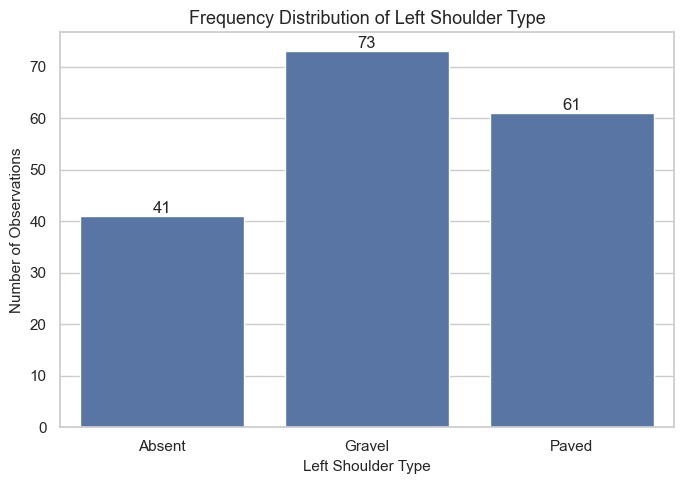

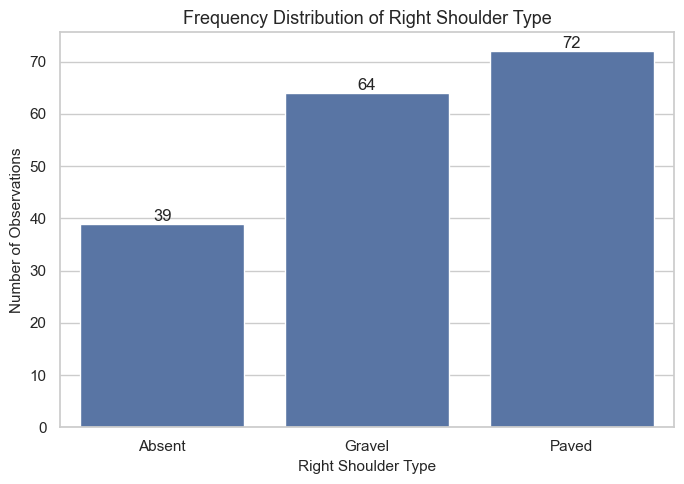

In [31]:
# ============================================================
# EDA STEP 5: SHOULDER-TYPE COUNT PLOTS
# ============================================================

for column in categorical_variables:

    plt.figure(figsize=(7, 5))

    ax = sns.countplot(
        data=df,
        x=column,
        order=["Absent", "Gravel", "Paved"]
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"Frequency Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Observations")
    plt.tight_layout()
    plt.show()

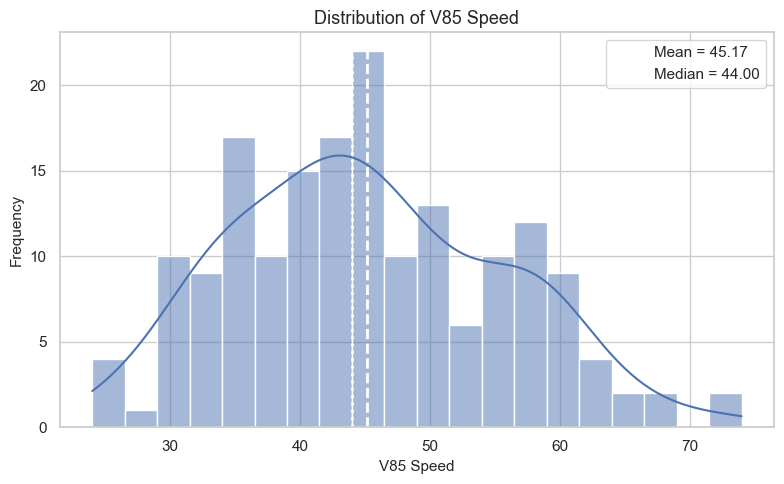

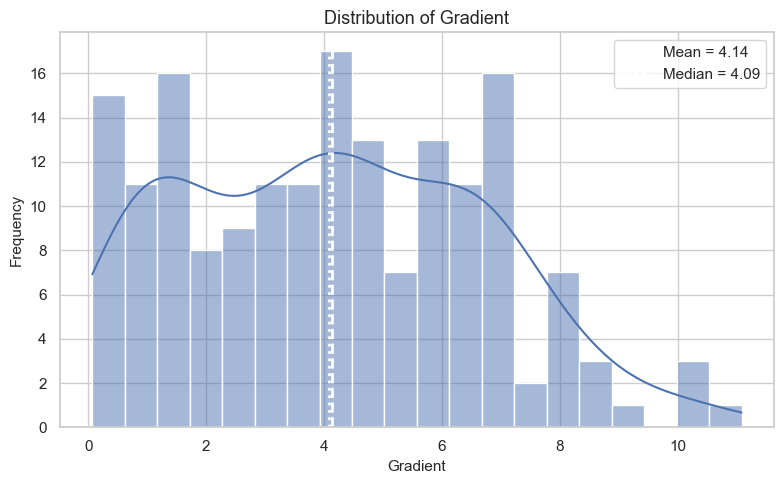

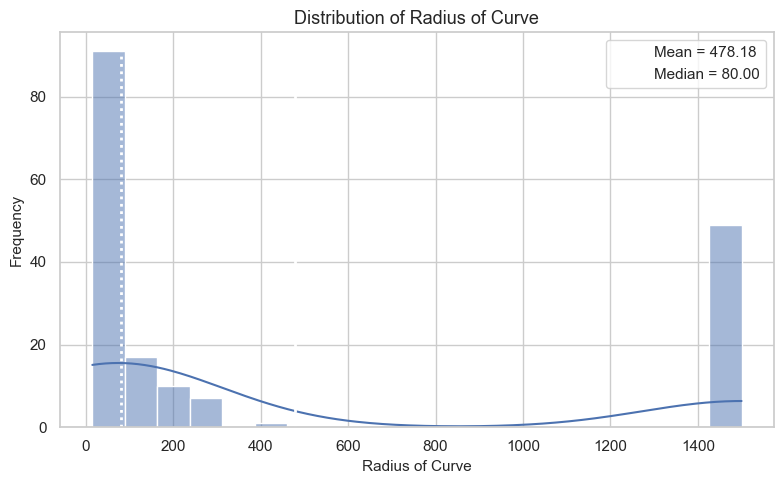

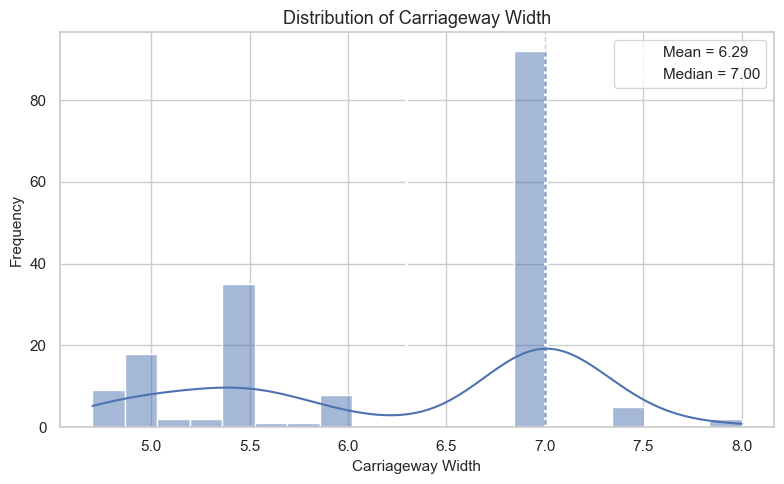

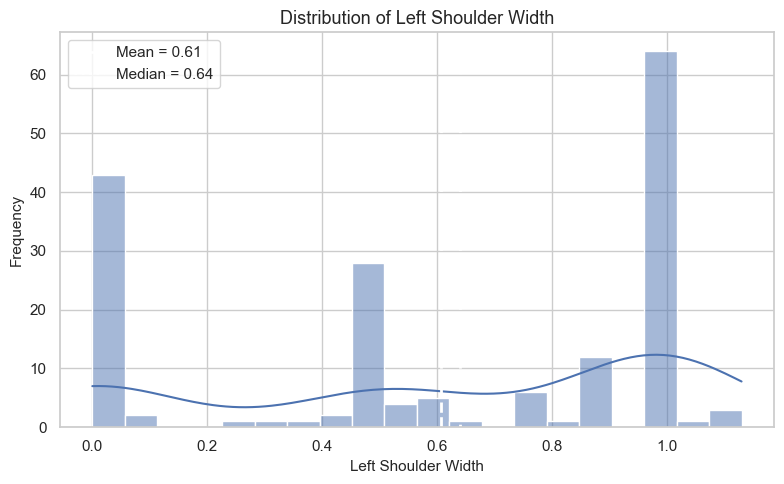

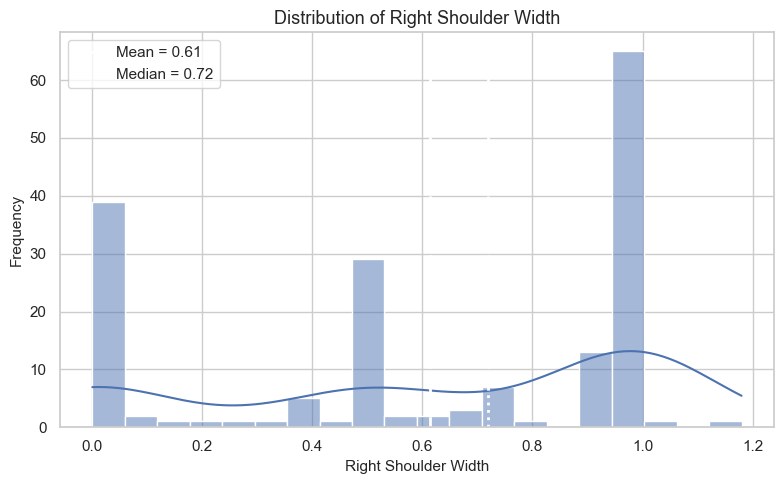

In [32]:
# ============================================================
# EDA STEP 6: DISTRIBUTION OF NUMERICAL VARIABLES
# ============================================================

for column in numeric_variables:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=20,
        kde=True
    )

    plt.axvline(
        df[column].mean(),
        linestyle="--",
        linewidth=2,
        label=f"Mean = {df[column].mean():.2f}"
    )

    plt.axvline(
        df[column].median(),
        linestyle=":",
        linewidth=2,
        label=f"Median = {df[column].median():.2f}"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.show()

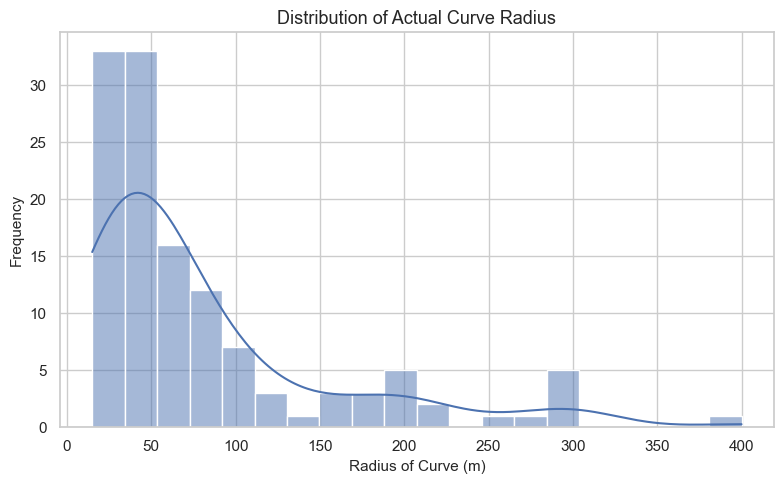

In [33]:
# ============================================================
# EDA STEP 7: RADIUS DISTRIBUTION BY SECTION TYPE
# ============================================================

curve_data = df[df["Is_Tangent"] == 0].copy()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=curve_data,
    x="Radius of Curve",
    bins=20,
    kde=True
)

plt.title("Distribution of Actual Curve Radius")
plt.xlabel("Radius of Curve (m)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

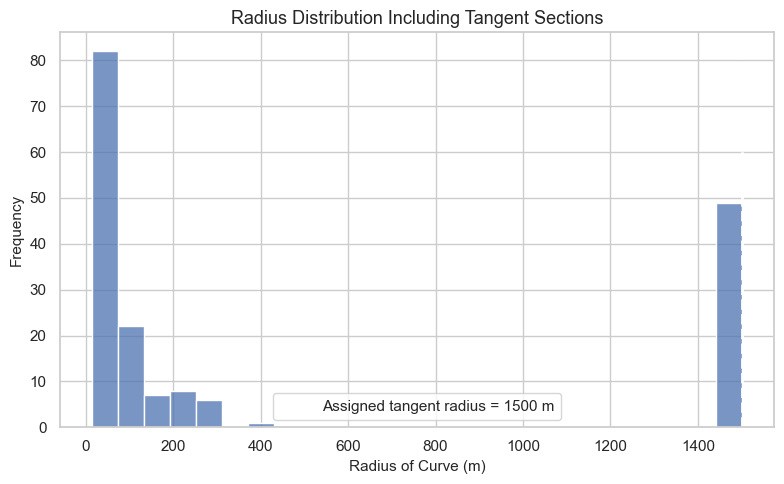

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Radius of Curve",
    bins=25
)

plt.axvline(
    1500,
    linestyle="--",
    linewidth=2,
    label="Assigned tangent radius = 1500 m"
)

plt.title("Radius Distribution Including Tangent Sections")
plt.xlabel("Radius of Curve (m)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

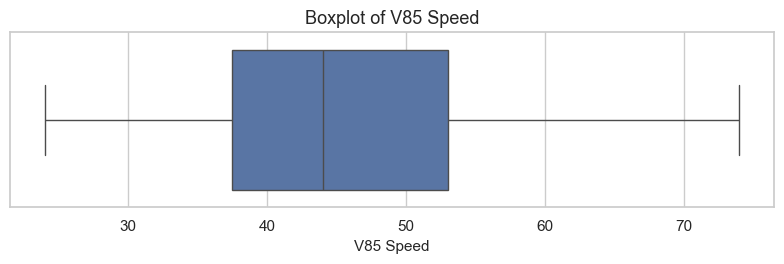

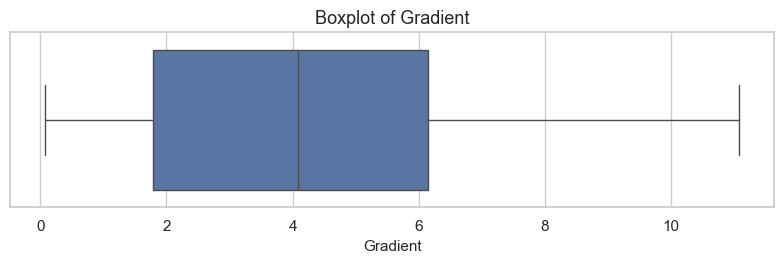

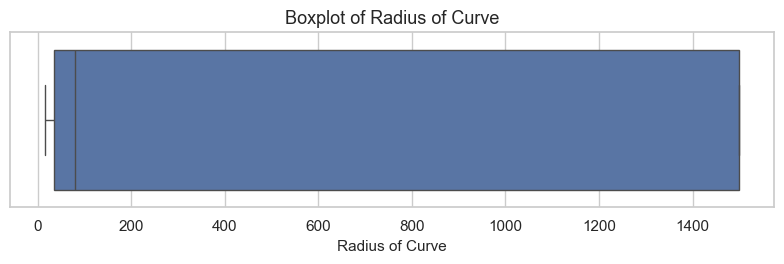

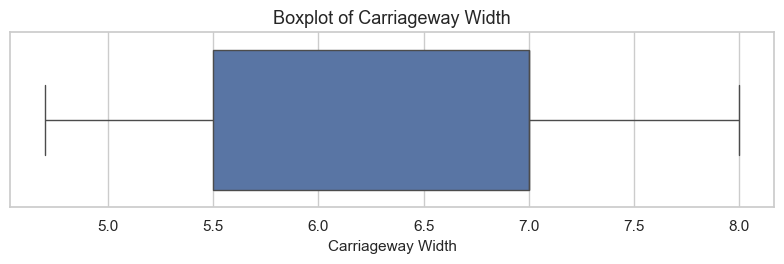

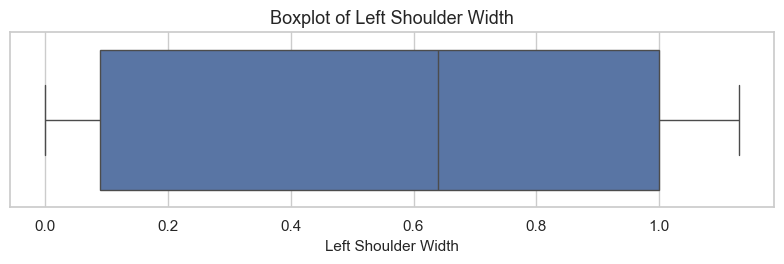

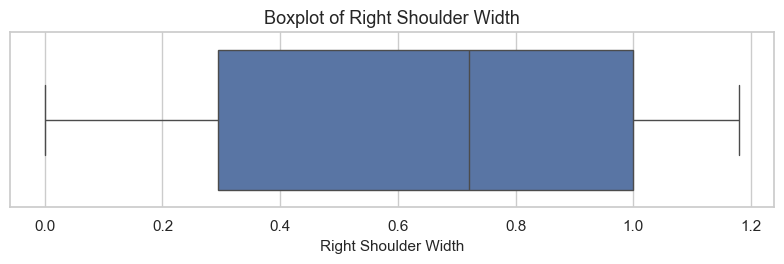

In [35]:
# ============================================================
# EDA STEP 8: BOXPLOTS FOR NUMERICAL VARIABLES
# ============================================================

for column in numeric_variables:

    plt.figure(figsize=(8, 2.8))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [36]:
# ============================================================
# EDA STEP 9: IQR OUTLIER SCREENING
# ============================================================

outlier_results = []

outlier_rows = {}

for column in numeric_variables:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    flagged = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ].copy()

    outlier_rows[column] = flagged

    outlier_results.append({
        "Variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit,
        "Flagged Observations": len(flagged),
        "Flagged Percentage": (
            len(flagged) / len(df) * 100
        )
    })

outlier_table = pd.DataFrame(
    outlier_results
).round(3)

display(outlier_table)

,Variable,Q1,Q3,IQR,Lower Limit,Upper Limit,Flagged Observations,Flagged Percentage
0,V85 Speed,37.500,53.000,15.500,14.250,76.250,0,0.000
1,Gradient,1.792,6.142,4.350,-4.732,12.667,0,0.000
2,Radius of Curve,35.000,1500.000,1465.000,-2162.500,3697.500,0,0.000
3,Carriageway Width,5.500,7.000,1.500,3.250,9.250,0,0.000
4,Left Shoulder Width,0.090,1.000,0.910,-1.275,2.365,0,0.000
5,Right Shoulder Width,0.295,1.000,0.705,-0.762,2.058,0,0.000


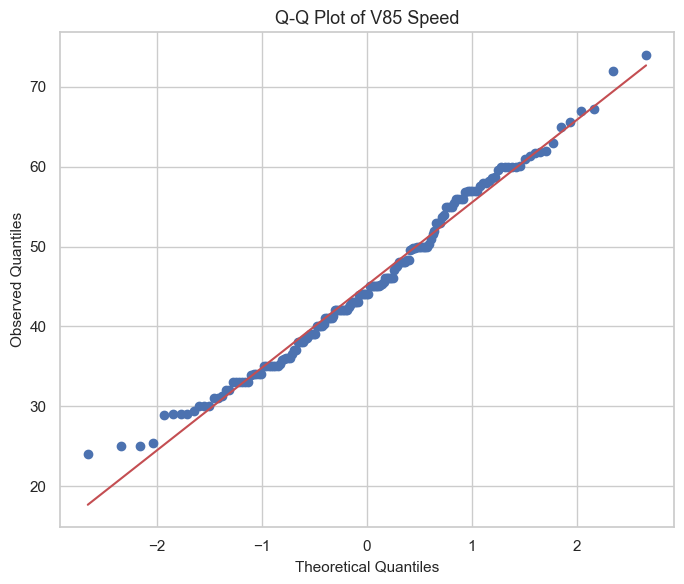

In [37]:
# ============================================================
# EDA STEP 10: Q-Q PLOT OF V85
# ============================================================

plt.figure(figsize=(7, 6))

probplot(
    df["V85 Speed"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of V85 Speed")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Observed Quantiles")
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# SHAPIRO-WILK TEST FOR V85
# ============================================================

shapiro_statistic, shapiro_pvalue = shapiro(
    df["V85 Speed"]
)

print("Shapiro-Wilk statistic:",
      round(shapiro_statistic, 4))

print("p-value:",
      round(shapiro_pvalue, 4))

if shapiro_pvalue > 0.05:
    print(
        "There is insufficient evidence to reject "
        "normality for V85."
    )
else:
    print(
        "The V85 distribution shows a statistically "
        "detectable departure from normality."
    )

Shapiro-Wilk statistic: 0.9841
p-value: 0.0444
The V85 distribution shows a statistically detectable departure from normality.


In [39]:
# ============================================================
# EDA STEP 11: CURVE VERSUS TANGENT SUMMARY
# ============================================================

section_summary = (
    df.groupby("Section Type")
    .agg(
        Observations=("V85 Speed", "count"),
        Mean_V85=("V85 Speed", "mean"),
        Median_V85=("V85 Speed", "median"),
        SD_V85=("V85 Speed", "std"),
        Minimum_V85=("V85 Speed", "min"),
        Maximum_V85=("V85 Speed", "max"),
        Mean_Gradient=("Gradient", "mean"),
        Mean_Carriageway_Width=(
            "Carriageway Width",
            "mean"
        ),
        Mean_Left_Shoulder_Width=(
            "Left Shoulder Width",
            "mean"
        ),
        Mean_Right_Shoulder_Width=(
            "Right Shoulder Width",
            "mean"
        )
    )
    .round(3)
)

display(section_summary)

,Observations,Mean_V85,Median_V85,SD_V85,Minimum_V85,Maximum_V85,Mean_Gradient,Mean_Carriageway_Width,Mean_Left_Shoulder_Width,Mean_Right_Shoulder_Width
Section Type,,,,,,,,,,
Horizontal Curve,126,41.785,42.000,8.699,24.000,65.650,4.450,6.279,0.607,0.636
Tangent,49,53.879,56.000,9.055,28.900,74.000,3.356,6.334,0.607,0.558


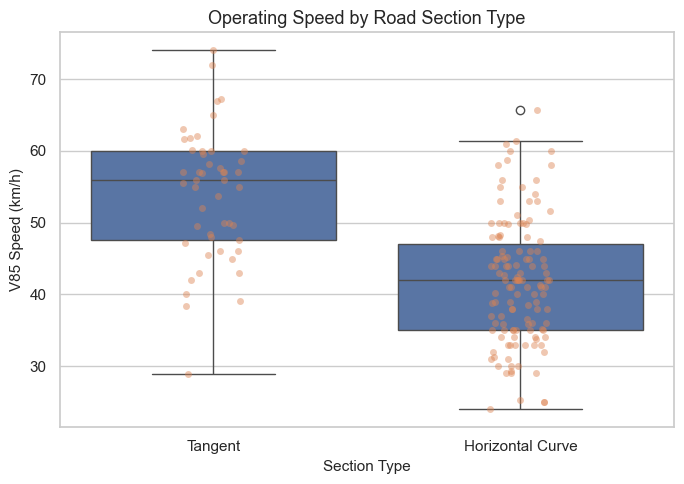

In [40]:
# ============================================================
# EDA STEP 12: V85 BY SECTION TYPE
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Section Type",
    y="V85 Speed"
)

sns.stripplot(
    data=df,
    x="Section Type",
    y="V85 Speed",
    alpha=0.45,
    jitter=True
)

plt.title("Operating Speed by Road Section Type")
plt.xlabel("Section Type")
plt.ylabel("V85 Speed (km/h)")
plt.tight_layout()
plt.show()

In [41]:
# ============================================================
# EDA STEP 13: NUMERICAL RELATIONSHIPS WITH V85
# ============================================================

relationship_results = []

for predictor in predictor_numeric_variables:

    pearson_r, pearson_p = pearsonr(
        df[predictor],
        df["V85 Speed"]
    )

    spearman_rho, spearman_p = spearmanr(
        df[predictor],
        df["V85 Speed"]
    )

    relationship_results.append({
        "Predictor": predictor,
        "Pearson r": pearson_r,
        "Pearson p-value": pearson_p,
        "Spearman rho": spearman_rho,
        "Spearman p-value": spearman_p
    })

relationship_table = pd.DataFrame(
    relationship_results
)

relationship_table["Absolute Pearson r"] = (
    relationship_table["Pearson r"].abs()
)

relationship_table = (
    relationship_table
    .sort_values(
        "Absolute Pearson r",
        ascending=False
    )
    .drop(columns="Absolute Pearson r")
    .reset_index(drop=True)
)

display(relationship_table.round(4))

,Predictor,Pearson r,Pearson p-value,Spearman rho,Spearman p-value
0,Radius of Curve,0.559,0.000,0.722,0.000
1,Right Shoulder Width,-0.186,0.014,-0.241,0.001
2,Left Shoulder Width,-0.135,0.076,-0.208,0.006
3,Gradient,-0.089,0.240,-0.116,0.126
4,Carriageway Width,0.071,0.351,0.073,0.340


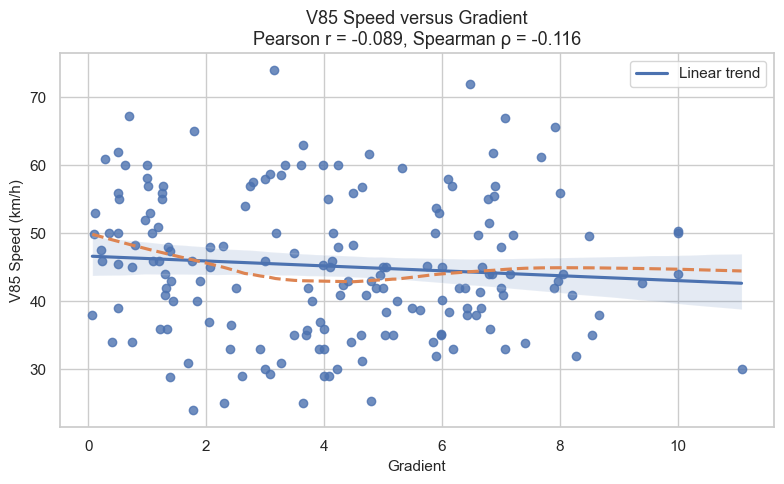

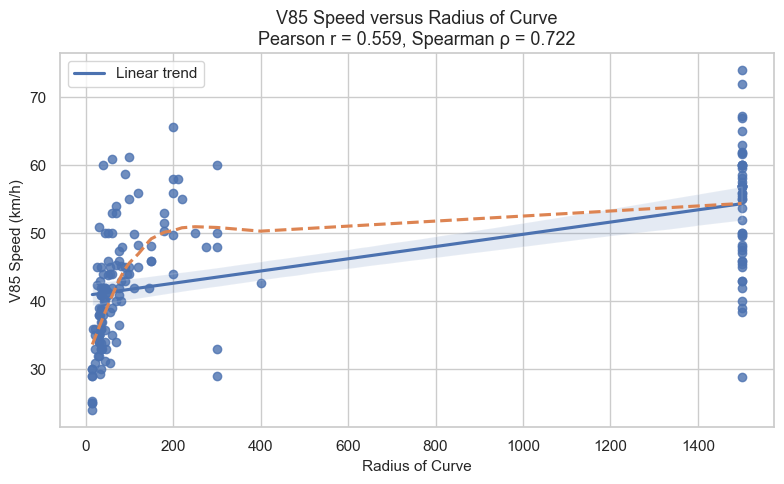

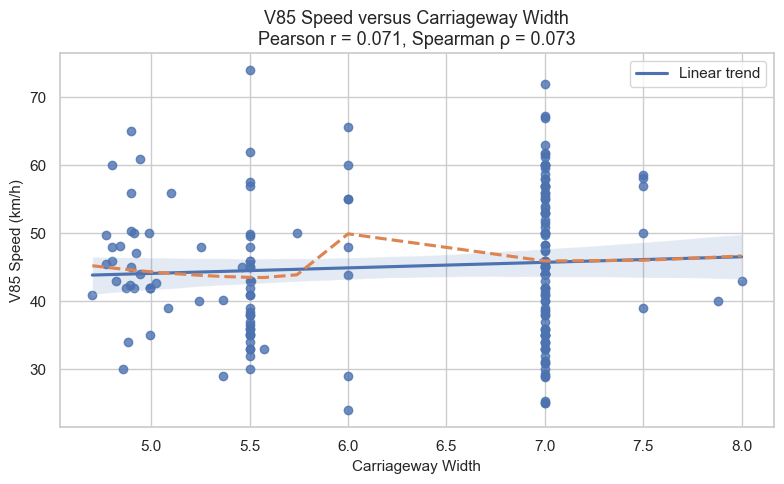

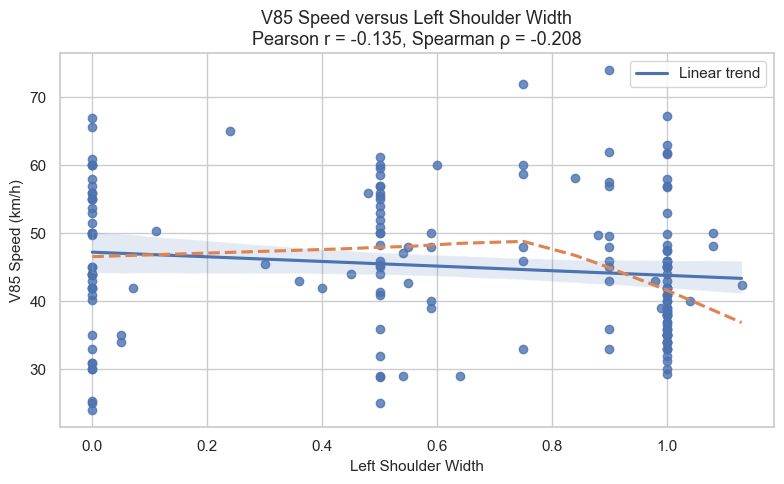

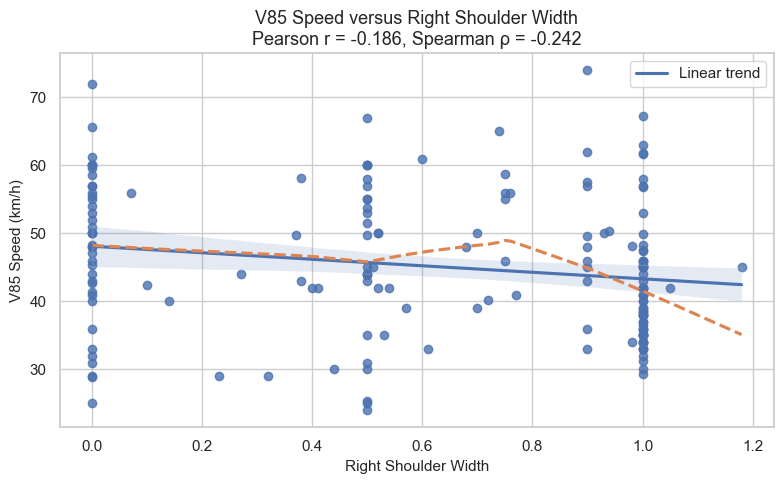

In [42]:
# ============================================================
# EDA STEP 14: SCATTERPLOTS AGAINST V85
# ============================================================

for predictor in predictor_numeric_variables:

    pearson_r = df[
        [predictor, "V85 Speed"]
    ].corr(method="pearson").iloc[0, 1]

    spearman_r = df[
        [predictor, "V85 Speed"]
    ].corr(method="spearman").iloc[0, 1]

    plt.figure(figsize=(8, 5))

    # Scatter points and linear regression line
    sns.regplot(
        data=df,
        x=predictor,
        y="V85 Speed",
        ci=95,
        line_kws={
            "label": "Linear trend"
        }
    )

    # LOWESS trend for possible nonlinearity
    sns.regplot(
        data=df,
        x=predictor,
        y="V85 Speed",
        scatter=False,
        lowess=True,
        line_kws={
            "linestyle": "--",
            "label": "LOWESS trend"
        }
    )

    plt.title(
        f"V85 Speed versus {predictor}\n"
        f"Pearson r = {pearson_r:.3f}, "
        f"Spearman ρ = {spearman_r:.3f}"
    )

    plt.xlabel(predictor)
    plt.ylabel("V85 Speed (km/h)")
    plt.legend()
    plt.tight_layout()
    plt.show()

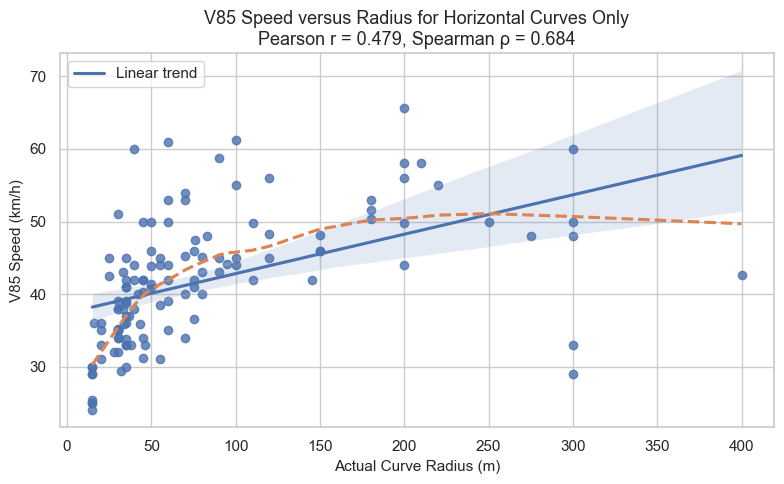

Curve-only Pearson p-value: 0.0
Curve-only Spearman p-value: 0.0


In [43]:
# ============================================================
# EDA STEP 15: CURVE RADIUS VERSUS V85, CURVES ONLY
# ============================================================

curve_only = df[df["Is_Tangent"] == 0].copy()

curve_pearson, curve_pearson_p = pearsonr(
    curve_only["Radius of Curve"],
    curve_only["V85 Speed"]
)

curve_spearman, curve_spearman_p = spearmanr(
    curve_only["Radius of Curve"],
    curve_only["V85 Speed"]
)

plt.figure(figsize=(8, 5))

sns.regplot(
    data=curve_only,
    x="Radius of Curve",
    y="V85 Speed",
    ci=95,
    line_kws={
        "label": "Linear trend"
    }
)

sns.regplot(
    data=curve_only,
    x="Radius of Curve",
    y="V85 Speed",
    scatter=False,
    lowess=True,
    line_kws={
        "linestyle": "--",
        "label": "LOWESS trend"
    }
)

plt.title(
    "V85 Speed versus Radius for Horizontal Curves Only\n"
    f"Pearson r = {curve_pearson:.3f}, "
    f"Spearman ρ = {curve_spearman:.3f}"
)

plt.xlabel("Actual Curve Radius (m)")
plt.ylabel("V85 Speed (km/h)")
plt.legend()
plt.tight_layout()
plt.show()

print("Curve-only Pearson p-value:",
      round(curve_pearson_p, 5))

print("Curve-only Spearman p-value:",
      round(curve_spearman_p, 5))

In [44]:
# ============================================================
# EDA STEP 16: V85 BY LEFT SHOULDER TYPE
# ============================================================

left_shoulder_v85 = (
    df.groupby("Left Shoulder Type")
    ["V85 Speed"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(3)
)

display(left_shoulder_v85)

,count,mean,median,std,min,max
Left Shoulder Type,,,,,,
Absent,41,46.446,45.000,11.490,24.000,67.000
Gravel,73,45.788,45.300,9.702,29.000,74.000
Paved,61,43.575,42.000,10.205,25.000,72.000


In [45]:
# ============================================================
# EDA STEP 16: V85 BY LEFT SHOULDER TYPE
# ============================================================

left_shoulder_v85 = (
    df.groupby("Left Shoulder Type")
    ["V85 Speed"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(3)
)

display(left_shoulder_v85)

,count,mean,median,std,min,max
Left Shoulder Type,,,,,,
Absent,41,46.446,45.000,11.490,24.000,67.000
Gravel,73,45.788,45.300,9.702,29.000,74.000
Paved,61,43.575,42.000,10.205,25.000,72.000


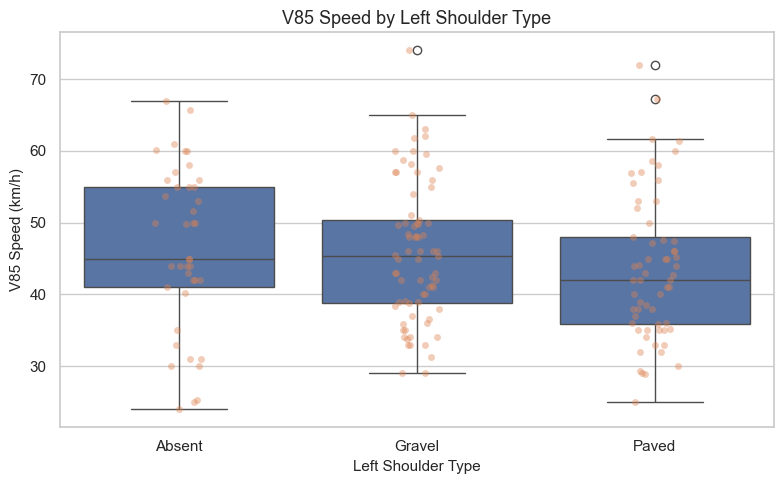

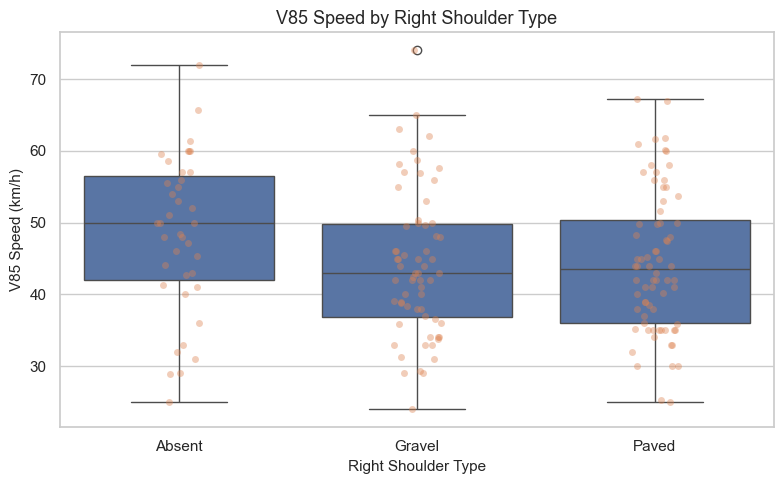

In [46]:
# ============================================================
# EDA STEP 18: SHOULDER-TYPE BOXPLOTS
# ============================================================

for column in categorical_variables:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=column,
        y="V85 Speed",
        order=["Absent", "Gravel", "Paved"]
    )

    sns.stripplot(
        data=df,
        x=column,
        y="V85 Speed",
        order=["Absent", "Gravel", "Paved"],
        alpha=0.40,
        jitter=True
    )

    plt.title(f"V85 Speed by {column}")
    plt.xlabel(column)
    plt.ylabel("V85 Speed (km/h)")
    plt.tight_layout()
    plt.show()

In [47]:
# ============================================================
# EDA STEP 19: CATEGORICAL ASSOCIATION TESTS
# ============================================================

categorical_test_results = []

for column in categorical_variables:

    grouped_values = [
        group["V85 Speed"].values
        for _, group in df.groupby(column)
    ]

    anova_statistic, anova_pvalue = f_oneway(
        *grouped_values
    )

    kruskal_statistic, kruskal_pvalue = kruskal(
        *grouped_values
    )

    overall_mean = df["V85 Speed"].mean()

    ss_between = sum(
        len(group) *
        (
            group["V85 Speed"].mean() -
            overall_mean
        ) ** 2
        for _, group in df.groupby(column)
    )

    ss_total = sum(
        (
            df["V85 Speed"] -
            overall_mean
        ) ** 2
    )

    eta_squared = ss_between / ss_total

    categorical_test_results.append({
        "Categorical Variable": column,
        "ANOVA F": anova_statistic,
        "ANOVA p-value": anova_pvalue,
        "Kruskal-Wallis H": kruskal_statistic,
        "Kruskal-Wallis p-value": kruskal_pvalue,
        "Eta Squared": eta_squared
    })

categorical_test_table = pd.DataFrame(
    categorical_test_results
).round(4)

display(categorical_test_table)

,Categorical Variable,ANOVA F,ANOVA p-value,Kruskal-Wallis H,Kruskal-Wallis p-value,Eta Squared
0,Left Shoulder Type,1.173,0.312,3.097,0.212,0.013
1,Right Shoulder Type,2.510,0.084,5.672,0.059,0.028


,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
V85 Speed,1.000,-0.089,0.559,0.071,-0.135,-0.186
Gradient,-0.089,1.000,-0.186,-0.147,-0.033,-0.040
Radius of Curve,0.559,-0.186,1.000,0.028,-0.012,-0.119
Carriageway Width,0.071,-0.147,0.028,1.000,0.060,-0.136
Left Shoulder Width,-0.135,-0.033,-0.012,0.060,1.000,0.484
Right Shoulder Width,-0.186,-0.040,-0.119,-0.136,0.484,1.000


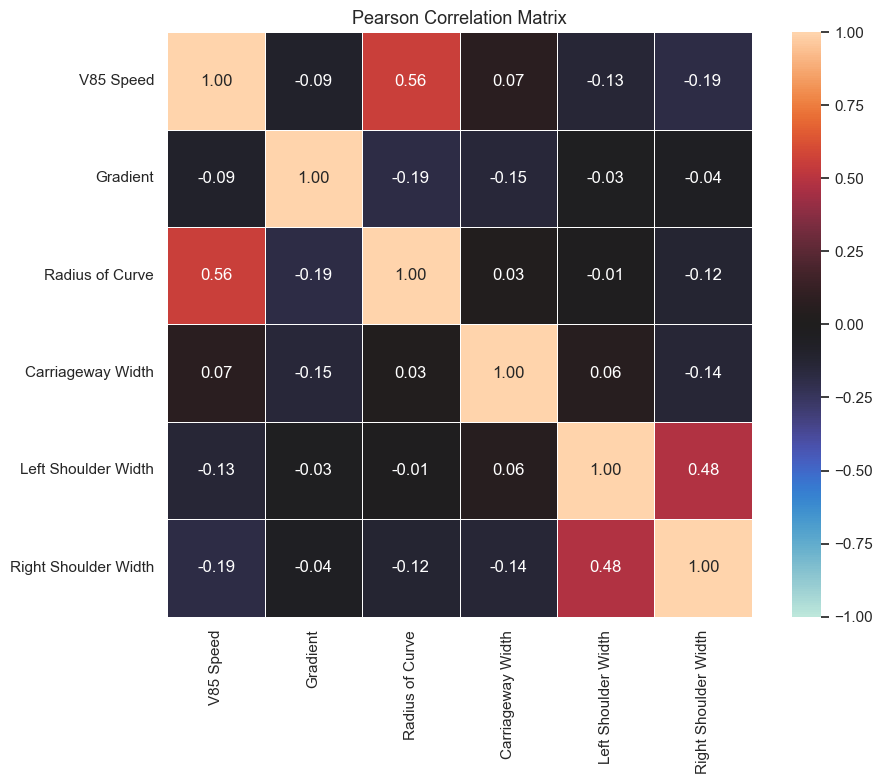

In [48]:
# ============================================================
# EDA STEP 20: PEARSON CORRELATION MATRIX
# ============================================================

pearson_correlation = df[
    numeric_variables
].corr(method="pearson")

display(
    pearson_correlation.round(3)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    pearson_correlation,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
V85 Speed,1.000,-0.116,0.722,0.073,-0.208,-0.242
Gradient,-0.116,1.000,-0.127,-0.125,-0.029,-0.016
Radius of Curve,0.722,-0.127,1.000,0.069,-0.127,-0.247
Carriageway Width,0.073,-0.125,0.069,1.000,0.073,-0.084
Left Shoulder Width,-0.208,-0.029,-0.127,0.073,1.000,0.636
Right Shoulder Width,-0.242,-0.016,-0.247,-0.084,0.636,1.000


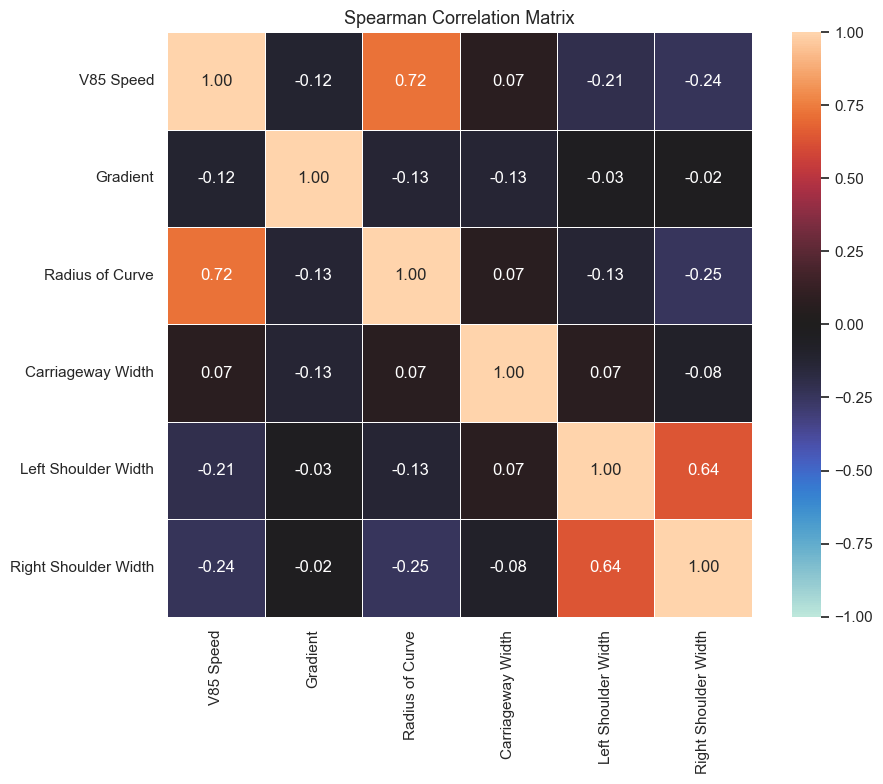

In [49]:
# ============================================================
# EDA STEP 21: SPEARMAN CORRELATION MATRIX
# ============================================================

spearman_correlation = df[
    numeric_variables
].corr(method="spearman")

display(
    spearman_correlation.round(3)
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [50]:
# ============================================================
# EDA STEP 22: CORRELATION WITH V85
# ============================================================

target_correlations = pd.DataFrame({
    "Pearson Correlation": (
        pearson_correlation["V85 Speed"]
        .drop("V85 Speed")
    ),
    "Spearman Correlation": (
        spearman_correlation["V85 Speed"]
        .drop("V85 Speed")
    )
})

target_correlations[
    "Absolute Pearson Correlation"
] = target_correlations[
    "Pearson Correlation"
].abs()

target_correlations = (
    target_correlations
    .sort_values(
        "Absolute Pearson Correlation",
        ascending=False
    )
    .drop(
        columns="Absolute Pearson Correlation"
    )
)

display(target_correlations.round(3))

,Pearson Correlation,Spearman Correlation
Radius of Curve,0.559,0.722
Right Shoulder Width,-0.186,-0.242
Left Shoulder Width,-0.135,-0.208
Gradient,-0.089,-0.116
Carriageway Width,0.071,0.073


In [51]:
# ============================================================
# EDA STEP 23: LEFT-RIGHT SHOULDER-TYPE CROSS-TABULATION
# ============================================================

shoulder_type_crosstab = pd.crosstab(
    df["Left Shoulder Type"],
    df["Right Shoulder Type"],
    margins=True
)

display(shoulder_type_crosstab)

Right Shoulder Type,Absent,Gravel,Paved,All
Left Shoulder Type,,,,
Absent,4,9,28,41
Gravel,17,43,13,73
Paved,18,12,31,61
All,39,64,72,175


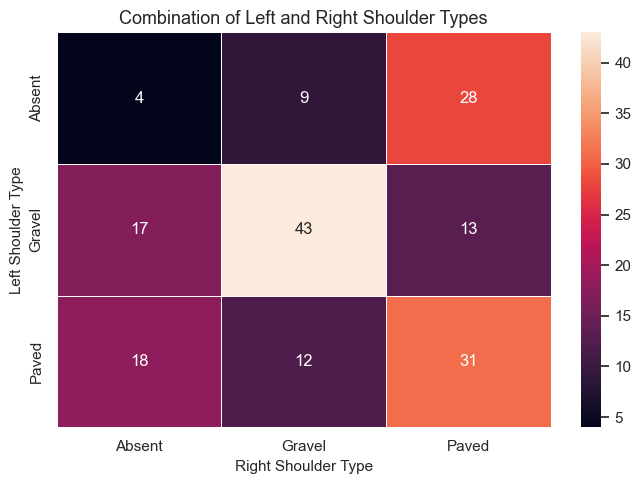

In [52]:
# ============================================================
# SHOULDER-TYPE COMBINATION HEATMAP
# ============================================================

shoulder_type_crosstab_no_total = pd.crosstab(
    df["Left Shoulder Type"],
    df["Right Shoulder Type"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    shoulder_type_crosstab_no_total,
    annot=True,
    fmt="d",
    linewidths=0.5
)

plt.title("Combination of Left and Right Shoulder Types")
plt.xlabel("Right Shoulder Type")
plt.ylabel("Left Shoulder Type")
plt.tight_layout()
plt.show()

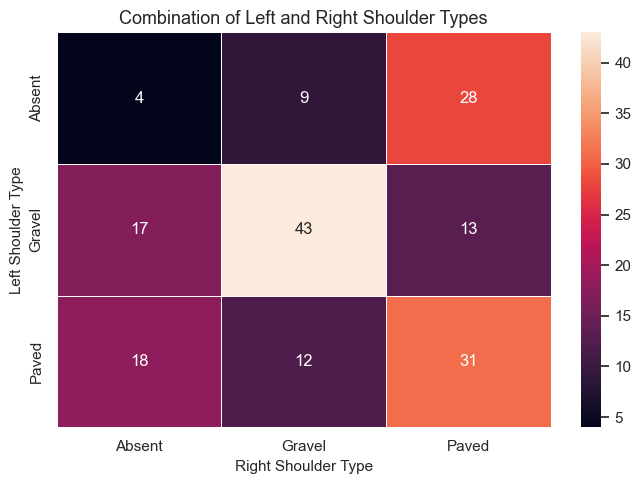

In [53]:
# ============================================================
# SHOULDER-TYPE COMBINATION HEATMAP
# ============================================================

shoulder_type_crosstab_no_total = pd.crosstab(
    df["Left Shoulder Type"],
    df["Right Shoulder Type"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    shoulder_type_crosstab_no_total,
    annot=True,
    fmt="d",
    linewidths=0.5
)

plt.title("Combination of Left and Right Shoulder Types")
plt.xlabel("Right Shoulder Type")
plt.ylabel("Left Shoulder Type")
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# ENCODING STEP 1: CREATE ENCODED DATASET
# ============================================================

features_before_encoding = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Left Shoulder Type",
    "Right Shoulder Width",
    "Right Shoulder Type"
]

X_full = pd.get_dummies(
    df[features_before_encoding],
    columns=[
        "Left Shoulder Type",
        "Right Shoulder Type"
    ],
    drop_first=True,
    dtype=int
)

y = df["V85 Speed"].copy()

print("Encoded predictors:")
for column in X_full.columns:
    print(column)

print("\nNumber of predictors:", X_full.shape[1])

display(X_full.head())

Encoded predictors:
Gradient
Radius of Curve
Carriageway Width
Left Shoulder Width
Right Shoulder Width
Left Shoulder Type_Gravel
Left Shoulder Type_Paved
Right Shoulder Type_Gravel
Right Shoulder Type_Paved

Number of predictors: 9


,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
0,1.270,1500.000,5.500,0.900,0.900,1,0,1,0
1,2.920,46.000,5.500,0.900,0.900,1,0,1,0
2,7.970,1500.000,5.500,0.900,0.900,1,0,1,0
3,2.070,1500.000,5.500,0.900,0.900,1,0,1,0
4,1.210,16.000,5.500,0.900,0.900,1,0,1,0


In [55]:
# ============================================================
# ENCODING STEP 2: VALIDATE ENCODED DATA
# ============================================================

print("Missing encoded values:",
      X_full.isna().sum().sum())

print(
    "Infinite encoded values:",
    np.isinf(
        X_full.select_dtypes(include=np.number)
    ).sum().sum()
)

print("Encoded dataset shape:", X_full.shape)

Missing encoded values: 0
Infinite encoded values: 0
Encoded dataset shape: (175, 9)


,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,Right Shoulder Type_Paved
V85 Speed,1.000,-0.089,0.559,0.071,-0.135,-0.186,0.051,-0.113,-0.083,-0.061
Gradient,-0.089,1.000,-0.186,-0.147,-0.033,-0.040,-0.174,0.160,-0.093,0.097
Radius of Curve,0.559,-0.186,1.000,0.028,-0.012,-0.119,0.156,-0.092,0.121,-0.225
Carriageway Width,0.071,-0.147,0.028,1.000,0.060,-0.136,-0.086,0.089,-0.224,0.015
Left Shoulder Width,-0.135,-0.033,-0.012,0.060,1.000,0.484,0.335,0.387,0.187,-0.046
Right Shoulder Width,-0.186,-0.040,-0.119,-0.136,0.484,1.000,0.053,0.063,0.303,0.399
Left Shoulder Type_Gravel,0.051,-0.174,0.156,-0.086,0.335,0.053,1.000,-0.619,0.392,-0.401
Left Shoulder Type_Paved,-0.113,0.160,-0.092,0.089,0.387,0.063,-0.619,1.000,-0.257,0.144
Right Shoulder Type_Gravel,-0.083,-0.093,0.121,-0.224,0.187,0.303,0.392,-0.257,1.000,-0.635
Right Shoulder Type_Paved,-0.061,0.097,-0.225,0.015,-0.046,0.399,-0.401,0.144,-0.635,1.000


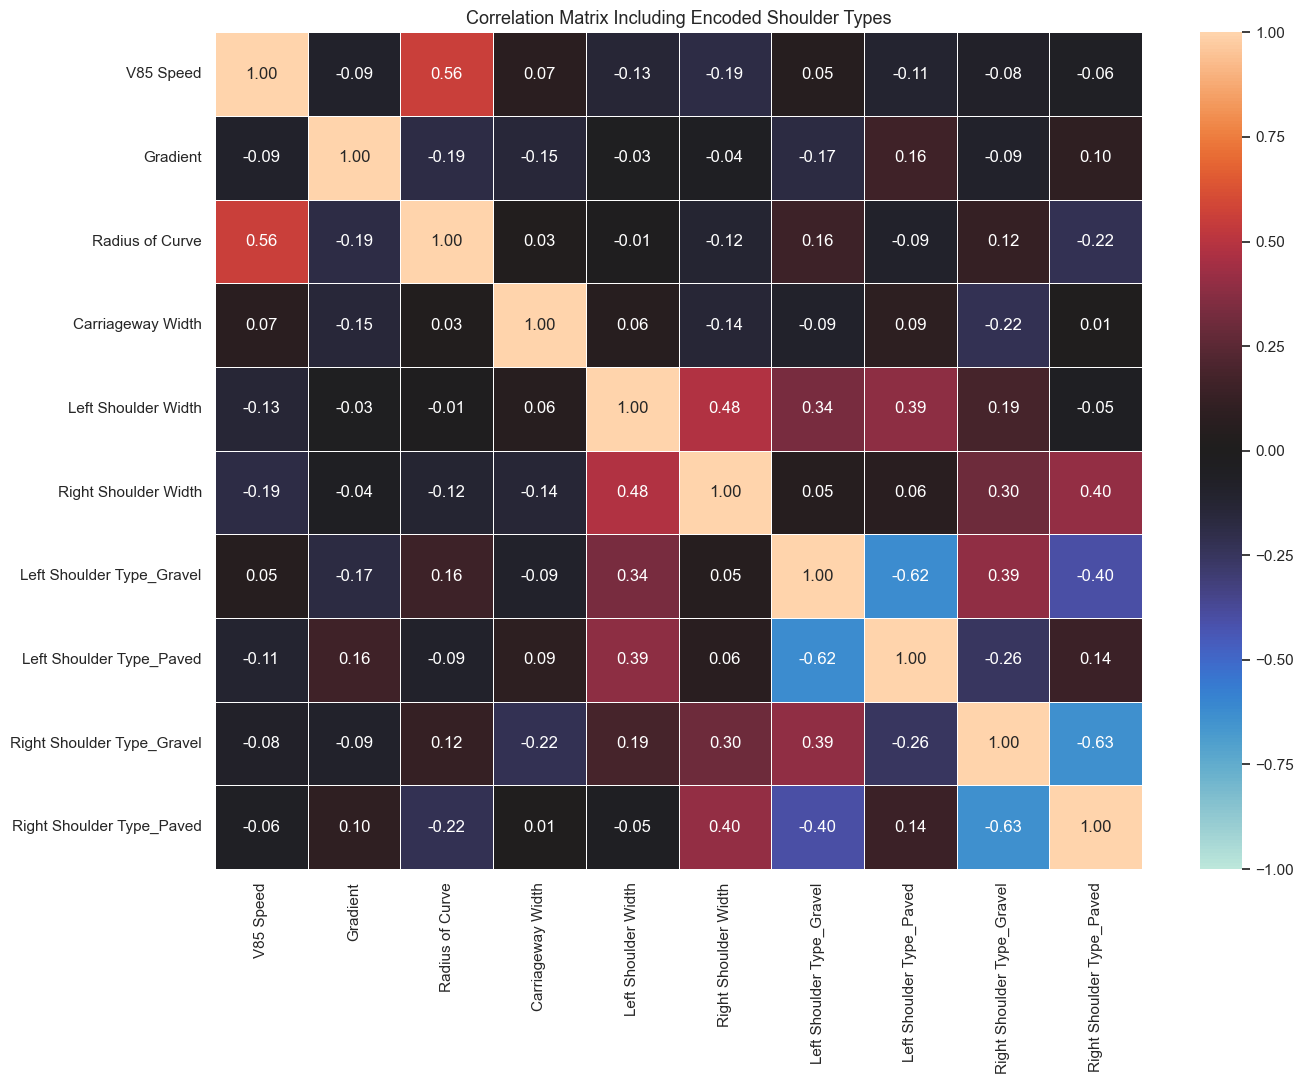

In [56]:
# ============================================================
# EDA STEP 25: FULL ENCODED CORRELATION MATRIX
# ============================================================

encoded_for_correlation = X_full.copy()

encoded_for_correlation.insert(
    0,
    "V85 Speed",
    y
)

encoded_correlation = (
    encoded_for_correlation
    .corr(method="pearson")
)

display(encoded_correlation.round(3))

plt.figure(figsize=(14, 11))

sns.heatmap(
    encoded_correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    square=False,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title(
    "Correlation Matrix Including Encoded Shoulder Types"
)

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# EDA STEP 26: HIGH-CORRELATION PAIRS
# ============================================================

predictor_correlation = X_full.corr()

correlation_pairs = []

columns = predictor_correlation.columns

for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        correlation_value = (
            predictor_correlation.iloc[i, j]
        )

        correlation_pairs.append({
            "Variable 1": columns[i],
            "Variable 2": columns[j],
            "Correlation": correlation_value,
            "Absolute Correlation": abs(
                correlation_value
            )
        })

correlation_pairs = (
    pd.DataFrame(correlation_pairs)
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    correlation_pairs.head(20).round(3)
)

,Variable 1,Variable 2,Correlation,Absolute Correlation
0,Right Shoulder Type_Gravel,Right Shoulder Type_Paved,-0.635,0.635
1,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,-0.619,0.619
2,Left Shoulder Width,Right Shoulder Width,0.484,0.484
3,Left Shoulder Type_Gravel,Right Shoulder Type_Paved,-0.401,0.401
4,Right Shoulder Width,Right Shoulder Type_Paved,0.399,0.399
5,Left Shoulder Type_Gravel,Right Shoulder Type_Gravel,0.392,0.392
6,Left Shoulder Width,Left Shoulder Type_Paved,0.387,0.387
7,Left Shoulder Width,Left Shoulder Type_Gravel,0.335,0.335
8,Right Shoulder Width,Right Shoulder Type_Gravel,0.303,0.303
9,Left Shoulder Type_Paved,Right Shoulder Type_Gravel,-0.257,0.257


In [58]:
strong_correlation_pairs = correlation_pairs[
    correlation_pairs["Absolute Correlation"] >= 0.50
]

display(
    strong_correlation_pairs.round(3)
)

,Variable 1,Variable 2,Correlation,Absolute Correlation
0,Right Shoulder Type_Gravel,Right Shoulder Type_Paved,-0.635,0.635
1,Left Shoulder Type_Gravel,Left Shoulder Type_Paved,-0.619,0.619


In [59]:
# ============================================================
# VIF STEP 1: VIF FUNCTION
# ============================================================

def calculate_vif(X):

    X_numeric = X.copy().astype(float)

    X_with_constant = sm.add_constant(
        X_numeric,
        has_constant="add"
    )

    vif_table = pd.DataFrame({
        "Feature": X_with_constant.columns,
        "VIF": [
            variance_inflation_factor(
                X_with_constant.values,
                index
            )
            for index in range(
                X_with_constant.shape[1]
            )
        ]
    })

    vif_table["Tolerance"] = np.where(
        vif_table["VIF"] != 0,
        1 / vif_table["VIF"],
        np.nan
    )

    def classify_vif(value):

        if value < 5:
            return "Low"

        elif value < 10:
            return "Moderate"

        else:
            return "Severe"

    vif_table["Interpretation"] = (
        vif_table["VIF"]
        .apply(classify_vif)
    )

    return vif_table

In [60]:
# ============================================================
# VIF STEP 2: FULL PREDICTOR SET
# ============================================================

vif_full = calculate_vif(
    X_full
)

display(
    vif_full.round(3)
)

,Feature,VIF,Tolerance,Interpretation
0,const,94.726,0.011,Severe
1,Gradient,1.110,0.901,Low
2,Radius of Curve,1.094,0.914,Low
3,Carriageway Width,1.205,0.830,Low
4,Left Shoulder Width,6.248,0.160,Moderate
5,Right Shoulder Width,5.408,0.185,Moderate
6,Left Shoulder Type_Gravel,7.401,0.135,Moderate
7,Left Shoulder Type_Paved,7.246,0.138,Moderate
8,Right Shoulder Type_Gravel,6.057,0.165,Moderate
9,Right Shoulder Type_Paved,7.223,0.138,Moderate


In [61]:
# ============================================================
# VIF CANDIDATE 1:
# NUMERIC GEOMETRY + LEFT AND RIGHT SHOULDER WIDTHS
# ============================================================

candidate_1_columns = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Width",
    "Right Shoulder Width"
]

X_candidate_1 = df[
    candidate_1_columns
].copy()

vif_candidate_1 = calculate_vif(
    X_candidate_1
)

display(
    vif_candidate_1.round(3)
)

,Feature,VIF,Tolerance,Interpretation
0,const,66.588,0.015,Severe
1,Gradient,1.066,0.938,Low
2,Radius of Curve,1.057,0.946,Low
3,Carriageway Width,1.067,0.938,Low
4,Left Shoulder Width,1.337,0.748,Low
5,Right Shoulder Width,1.385,0.722,Low


In [62]:
# ============================================================
# VIF CANDIDATE 2:
# GEOMETRY + SHOULDER TYPES, WITHOUT SHOULDER WIDTHS
# ============================================================

candidate_2_columns = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Left Shoulder Type",
    "Right Shoulder Type"
]

X_candidate_2 = pd.get_dummies(
    df[candidate_2_columns],
    columns=[
        "Left Shoulder Type",
        "Right Shoulder Type"
    ],
    drop_first=True,
    dtype=int
)

vif_candidate_2 = calculate_vif(
    X_candidate_2
)

display(
    vif_candidate_2.round(3)
)

,Feature,VIF,Tolerance,Interpretation
0,const,80.942,0.012,Severe
1,Gradient,1.098,0.911,Low
2,Radius of Curve,1.090,0.918,Low
3,Carriageway Width,1.120,0.893,Low
4,Left Shoulder Type_Gravel,1.960,0.510,Low
5,Left Shoulder Type_Paved,1.692,0.591,Low
6,Right Shoulder Type_Gravel,1.909,0.524,Low
7,Right Shoulder Type_Paved,1.929,0.518,Low


In [63]:
# ============================================================
# VIF CANDIDATE 3:
# AVERAGE SHOULDER WIDTH + LEFT/RIGHT SHOULDER TYPES
# ============================================================

df["Average Shoulder Width"] = (
    df["Left Shoulder Width"] +
    df["Right Shoulder Width"]
) / 2

candidate_3_columns = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width",
    "Left Shoulder Type",
    "Right Shoulder Type"
]

X_candidate_3 = pd.get_dummies(
    df[candidate_3_columns],
    columns=[
        "Left Shoulder Type",
        "Right Shoulder Type"
    ],
    drop_first=True,
    dtype=int
)

vif_candidate_3 = calculate_vif(
    X_candidate_3
)

display(
    vif_candidate_3.round(3)
)

,Feature,VIF,Tolerance,Interpretation
0,const,92.049,0.011,Severe
1,Gradient,1.105,0.905,Low
2,Radius of Curve,1.093,0.915,Low
3,Carriageway Width,1.176,0.851,Low
4,Average Shoulder Width,4.860,0.206,Low
5,Left Shoulder Type_Gravel,5.033,0.199,Moderate
6,Left Shoulder Type_Paved,4.952,0.202,Low
7,Right Shoulder Type_Gravel,4.795,0.209,Low
8,Right Shoulder Type_Paved,5.774,0.173,Moderate


In [64]:
# ============================================================
# CREATE AVERAGE SHOULDER WIDTH
# ============================================================

df["Average Shoulder Width"] = (
    df["Left Shoulder Width"] +
    df["Right Shoulder Width"]
) / 2

display(
    df[
        [
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ].head()
)

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.900,0.900,0.900
1,0.900,0.900,0.900
2,0.900,0.900,0.900
3,0.900,0.900,0.900
4,0.900,0.900,0.900


In [65]:
# ============================================================
# DEFINE VARIABLES FOR EDA AND MODELING
# Shoulder-type variables are excluded
# ============================================================

selected_predictors = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

target_variable = "V85 Speed"

selected_data = df[
    [target_variable] + selected_predictors
].copy()

print("Variables included in the analysis:")

for column in selected_data.columns:
    print(column)

display(selected_data.head())

Variables included in the analysis:
V85 Speed
Gradient
Radius of Curve
Carriageway Width
Average Shoulder Width


,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width
0,57.000,1.270,1500.000,5.500,0.900
1,33.000,2.920,46.000,5.500,0.900
2,43.000,7.970,1500.000,5.500,0.900
3,48.000,2.070,1500.000,5.500,0.900
4,36.000,1.210,16.000,5.500,0.900


In [66]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

selected_descriptive_statistics = (
    selected_data
    .describe()
    .T
)

selected_descriptive_statistics["Variance"] = (
    selected_data.var()
)

selected_descriptive_statistics["Range"] = (
    selected_descriptive_statistics["max"] -
    selected_descriptive_statistics["min"]
)

selected_descriptive_statistics["Skewness"] = (
    selected_data.skew()
)

selected_descriptive_statistics["Kurtosis"] = (
    selected_data.kurtosis()
)

selected_descriptive_statistics = (
    selected_descriptive_statistics[
        [
            "count",
            "mean",
            "std",
            "Variance",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "Range",
            "Skewness",
            "Kurtosis"
        ]
    ]
    .round(3)
)

display(selected_descriptive_statistics)

,count,mean,std,Variance,min,25%,50%,75%,max,Range,Skewness,Kurtosis
V85 Speed,175.000,45.171,10.327,106.645,24.000,37.500,44.000,53.000,74.000,50.000,0.289,-0.456
Gradient,175.000,4.144,2.559,6.550,0.070,1.792,4.090,6.142,11.085,11.015,0.251,-0.734
Radius of Curve,175.000,478.183,642.352,412616.484,15.000,35.000,80.000,1500.000,1500.000,1485.000,0.956,-1.057
Carriageway Width,175.000,6.295,0.901,0.812,4.700,5.500,7.000,7.000,8.000,3.300,-0.402,-1.451
Average Shoulder Width,175.000,0.610,0.348,0.121,0.000,0.250,0.590,1.000,1.030,1.030,0.017,-1.764


In [67]:
# ============================================================
# PEARSON CORRELATION MATRIX
# ============================================================

pearson_correlation = selected_data.corr(
    method="pearson"
)

print("Pearson correlation matrix:")

display(
    pearson_correlation.round(3)
)

Pearson correlation matrix:


,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width
V85 Speed,1.000,-0.089,0.559,0.071,-0.186
Gradient,-0.089,1.000,-0.186,-0.147,-0.042
Radius of Curve,0.559,-0.186,1.000,0.028,-0.075
Carriageway Width,0.071,-0.147,0.028,1.000,-0.043
Average Shoulder Width,-0.186,-0.042,-0.075,-0.043,1.000


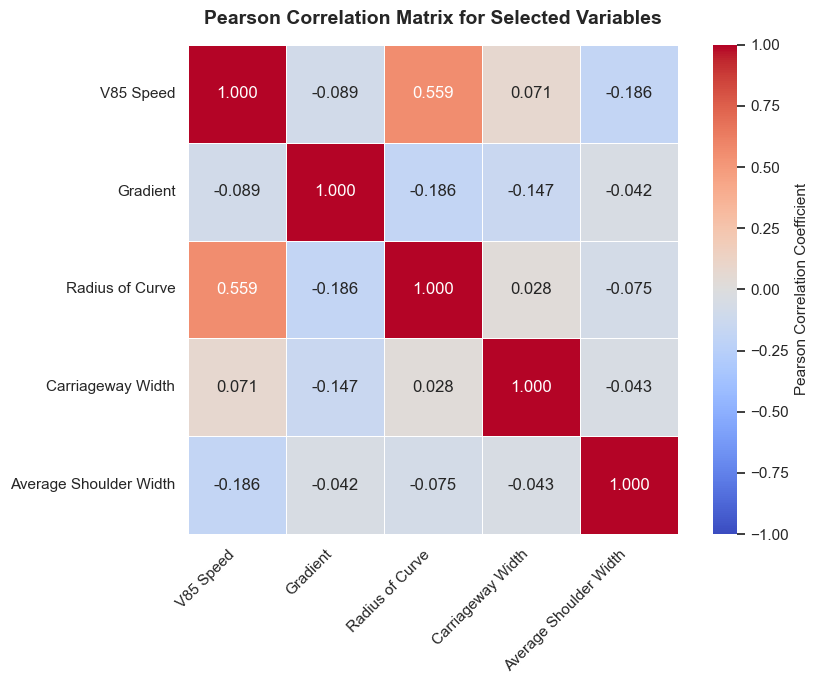

In [68]:
# ============================================================
# PEARSON CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    pearson_correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.7,
    cbar_kws={
        "label": "Pearson Correlation Coefficient"
    }
)

plt.title(
    "Pearson Correlation Matrix for Selected Variables",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# PEARSON CORRELATION WITH V85 SPEED
# ============================================================

v85_correlations = (
    pearson_correlation[target_variable]
    .drop(target_variable)
    .sort_values(
        key=abs,
        ascending=False
    )
    .to_frame(
        name="Pearson Correlation with V85"
    )
)

display(
    v85_correlations.round(4)
)

,Pearson Correlation with V85
Radius of Curve,0.559
Average Shoulder Width,-0.186
Gradient,-0.089
Carriageway Width,0.071


In [70]:
# ============================================================
# PEARSON CORRELATION COEFFICIENTS AND P-VALUES
# ============================================================

from scipy.stats import pearsonr

pearson_results = []

for predictor in selected_predictors:

    correlation_coefficient, p_value = pearsonr(
        selected_data[predictor],
        selected_data[target_variable]
    )

    if abs(correlation_coefficient) < 0.20:
        strength = "Very weak"

    elif abs(correlation_coefficient) < 0.40:
        strength = "Weak"

    elif abs(correlation_coefficient) < 0.60:
        strength = "Moderate"

    elif abs(correlation_coefficient) < 0.80:
        strength = "Strong"

    else:
        strength = "Very strong"

    significance = (
        "Significant"
        if p_value < 0.05
        else "Not significant"
    )

    pearson_results.append({
        "Predictor": predictor,
        "Pearson r": correlation_coefficient,
        "Absolute r": abs(correlation_coefficient),
        "p-value": p_value,
        "Relationship Strength": strength,
        "Significance at 5%": significance
    })

pearson_results_table = (
    pd.DataFrame(pearson_results)
    .sort_values(
        "Absolute r",
        ascending=False
    )
    .drop(columns="Absolute r")
    .reset_index(drop=True)
)

display(
    pearson_results_table.round(4)
)

,Predictor,Pearson r,p-value,Relationship Strength,Significance at 5%
0,Radius of Curve,0.559,0.000,Moderate,Significant
1,Average Shoulder Width,-0.186,0.014,Very weak,Significant
2,Gradient,-0.089,0.240,Very weak,Not significant
3,Carriageway Width,0.071,0.351,Very weak,Not significant


In [71]:
# ============================================================
# PREPARE INDEPENDENT VARIABLES FOR VIF
# ============================================================

X_vif = selected_data[
    selected_predictors
].copy()

print("Predictors included in VIF analysis:")

for column in X_vif.columns:
    print(column)

display(X_vif.head())

Predictors included in VIF analysis:
Gradient
Radius of Curve
Carriageway Width
Average Shoulder Width


,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width
0,1.270,1500.000,5.500,0.900
1,2.920,46.000,5.500,0.900
2,7.970,1500.000,5.500,0.900
3,2.070,1500.000,5.500,0.900
4,1.210,16.000,5.500,0.900


In [72]:
# ============================================================
# CALCULATE VARIANCE INFLATION FACTOR
# ============================================================

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

import statsmodels.api as sm

# Convert all variables to float
X_vif_numeric = X_vif.astype(float)

# Add an intercept for a statistically appropriate VIF calculation
X_vif_with_constant = sm.add_constant(
    X_vif_numeric,
    has_constant="add"
)

vif_results = pd.DataFrame({
    "Variable": X_vif_with_constant.columns,

    "VIF": [
        variance_inflation_factor(
            X_vif_with_constant.values,
            index
        )
        for index in range(
            X_vif_with_constant.shape[1]
        )
    ]
})

# Calculate tolerance
vif_results["Tolerance"] = (
    1 / vif_results["VIF"]
)

display(
    vif_results.round(3)
)

,Variable,VIF,Tolerance
0,const,63.664,0.016
1,Gradient,1.062,0.941
2,Radius of Curve,1.043,0.958
3,Carriageway Width,1.025,0.976
4,Average Shoulder Width,1.012,0.989


In [73]:
# ============================================================
# REMOVE CONSTANT FROM THE REPORTED VIF TABLE
# ============================================================

predictor_vif = (
    vif_results[
        vif_results["Variable"] != "const"
    ]
    .copy()
    .sort_values(
        "VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    predictor_vif.round(3)
)

,Variable,VIF,Tolerance
0,Gradient,1.062,0.941
1,Radius of Curve,1.043,0.958
2,Carriageway Width,1.025,0.976
3,Average Shoulder Width,1.012,0.989


In [74]:
# ============================================================
# INTERPRET VIF VALUES
# ============================================================

def interpret_vif(vif_value):

    if vif_value < 5:
        return "Low multicollinearity"

    elif vif_value < 10:
        return "Moderate multicollinearity"

    else:
        return "Severe multicollinearity"


predictor_vif["Interpretation"] = (
    predictor_vif["VIF"]
    .apply(interpret_vif)
)

predictor_vif["Decision"] = np.where(
    predictor_vif["VIF"] < 10,
    "Retain",
    "Investigate or remove"
)

display(
    predictor_vif.round(3)
)

,Variable,VIF,Tolerance,Interpretation,Decision
0,Gradient,1.062,0.941,Low multicollinearity,Retain
1,Radius of Curve,1.043,0.958,Low multicollinearity,Retain
2,Carriageway Width,1.025,0.976,Low multicollinearity,Retain
3,Average Shoulder Width,1.012,0.989,Low multicollinearity,Retain


In [75]:
# ============================================================
# CREATE AVERAGE SHOULDER WIDTH
# ============================================================

df["Average Shoulder Width"] = (
    df["Left Shoulder Width"] +
    df["Right Shoulder Width"]
) / 2

display(
    df[
        [
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ].head()
)

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.900,0.900,0.900
1,0.900,0.900,0.900
2,0.900,0.900,0.900
3,0.900,0.900,0.900
4,0.900,0.900,0.900


In [76]:
# ============================================================
# DEFINE INDEPENDENT AND DEPENDENT VARIABLES
# ============================================================

X = df[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Average Shoulder Width"
    ]
].copy()

y = df["V85 Speed"].copy()

print("Independent variables:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

Independent variables:
['Gradient', 'Radius of Curve', 'Carriageway Width', 'Average Shoulder Width']

X shape: (175, 4)
y shape: (175,)


,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width
0,1.270,1500.000,5.500,0.900
1,2.920,46.000,5.500,0.900
2,7.970,1500.000,5.500,0.900
3,2.070,1500.000,5.500,0.900
4,1.210,16.000,5.500,0.900


0   57.000
1   33.000
2   43.000
3   48.000
4   36.000
Name: V85 Speed, dtype: float64

In [77]:
# ============================================================
# VALIDATE MODELING DATA
# ============================================================

print("Missing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

print(
    "\nInfinite values in X:",
    np.isinf(X).sum().sum()
)

print(
    "Infinite values in y:",
    np.isinf(y).sum()
)

assert X.isna().sum().sum() == 0, (
    "Missing values are present in X."
)

assert y.isna().sum() == 0, (
    "Missing values are present in y."
)

assert not np.isinf(X).any().any(), (
    "Infinite values are present in X."
)

assert not np.isinf(y).any(), (
    "Infinite values are present in y."
)

print("\nThe modeling dataset passed all validation checks.")

Missing values in X:
Gradient                  0
Radius of Curve           0
Carriageway Width         0
Average Shoulder Width    0
dtype: int64

Missing values in y:
0

Infinite values in X: 0
Infinite values in y: 0

The modeling dataset passed all validation checks.


In [78]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (140, 4)
X_test shape : (35, 4)
y_train shape: (140,)
y_test shape : (35,)


In [79]:
# ============================================================
# CHECK TRAIN AND TEST TARGET DISTRIBUTIONS
# ============================================================

split_summary = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Observations": [
        len(y_train),
        len(y_test)
    ],
    "Mean V85": [
        y_train.mean(),
        y_test.mean()
    ],
    "Standard Deviation": [
        y_train.std(),
        y_test.std()
    ],
    "Minimum V85": [
        y_train.min(),
        y_test.min()
    ],
    "Maximum V85": [
        y_train.max(),
        y_test.max()
    ]
}).round(3)

display(split_summary)

,Dataset,Observations,Mean V85,Standard Deviation,Minimum V85,Maximum V85
0,Training,140,45.126,10.830,24.000,74.000
1,Testing,35,45.350,8.139,29.000,61.700


In [80]:
# ============================================================
# STANDARDIZE INDEPENDENT VARIABLES
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the training transformation to testing data
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

print("\nScaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

Training data scaled successfully.
Testing data scaled successfully.

Scaled training shape: (140, 4)
Scaled testing shape : (35, 4)


In [81]:
# ============================================================
# CHECK SCALED TRAINING DATA
# ============================================================

scaled_training_summary = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).agg(
    ["mean", "std"]
).T

display(
    scaled_training_summary.round(3)
)

,mean,std
Gradient,0.000,1.004
Radius of Curve,-0.000,1.004
Carriageway Width,-0.000,1.004
Average Shoulder Width,-0.000,1.004


In [82]:
# ============================================================
# CREATE SCALED DATAFRAMES FOR INSPECTION
# ============================================================

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

display(X_train_scaled_df.head())

,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width
118,-1.315,1.660,0.744,-1.051
143,0.595,-0.674,-0.944,1.094
164,0.822,-0.674,-0.944,1.094
38,1.439,-0.404,-1.624,-0.980
135,-0.487,-0.579,0.744,0.379


In [83]:
# ============================================================
# TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ============================================================

from sklearn.linear_model import LinearRegression

mlr = LinearRegression()

mlr.fit(
    X_train_scaled,
    y_train
)

print("MLR model trained successfully.")

MLR model trained successfully.


In [84]:
# ============================================================
# MLR PREDICTIONS
# ============================================================

y_train_pred_mlr = mlr.predict(
    X_train_scaled
)

y_test_pred_mlr = mlr.predict(
    X_test_scaled
)

print("Training predictions generated:", len(y_train_pred_mlr))
print("Testing predictions generated :", len(y_test_pred_mlr))

Training predictions generated: 140
Testing predictions generated : 35


In [85]:
# ============================================================
# MLR MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ------------------------------------------------------------
# Training performance
# ------------------------------------------------------------

mlr_train_r2 = r2_score(
    y_train,
    y_train_pred_mlr
)

mlr_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_mlr
    )
)

mlr_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_mlr
)

# ------------------------------------------------------------
# Testing performance
# ------------------------------------------------------------

mlr_test_r2 = r2_score(
    y_test,
    y_test_pred_mlr
)

mlr_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_mlr
    )
)

mlr_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_mlr
)

print("MLR evaluation completed.")

MLR evaluation completed.


In [86]:
# ============================================================
# MLR TRAINING AND TESTING RESULTS
# ============================================================

mlr_train_test_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "R2": [
        mlr_train_r2,
        mlr_test_r2
    ],
    "RMSE": [
        mlr_train_rmse,
        mlr_test_rmse
    ],
    "MAE": [
        mlr_train_mae,
        mlr_test_mae
    ]
})

display(
    mlr_train_test_results.round(3)
)

,Dataset,R2,RMSE,MAE
0,Training,0.360,8.632,6.711
1,Testing,0.127,7.494,5.718


In [87]:
# ============================================================
# MLR TEST-SET METRICS
# ============================================================

mlr_results = pd.DataFrame({
    "Metric": [
        "R2",
        "RMSE",
        "MAE"
    ],
    "Value": [
        mlr_test_r2,
        mlr_test_rmse,
        mlr_test_mae
    ]
})

display(
    mlr_results.round(3)
)

,Metric,Value
0,R2,0.127
1,RMSE,7.494
2,MAE,5.718


In [88]:
# ============================================================
# MLR COEFFICIENT TABLE
# ============================================================

coef_table_mlr = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": mlr.coef_
})

intercept_row = pd.DataFrame({
    "Variable": ["Constant"],
    "Coefficient": [mlr.intercept_]
})

coef_table_mlr = pd.concat(
    [
        intercept_row,
        coef_table_mlr
    ],
    ignore_index=True
)

coef_table_mlr["Coefficient"] = (
    coef_table_mlr["Coefficient"]
    .round(4)
)

display(coef_table_mlr)

,Variable,Coefficient
0,Constant,45.126
1,Gradient,0.028
2,Radius of Curve,6.145
3,Carriageway Width,0.659
4,Average Shoulder Width,-1.513


In [89]:
# ============================================================
# PRINT STANDARDIZED MLR EQUATION
# ============================================================

equation = f"V85 = {mlr.intercept_:.4f}"

for variable, coefficient in zip(
    X.columns,
    mlr.coef_
):
    sign = "+" if coefficient >= 0 else "-"

    equation += (
        f" {sign} "
        f"{abs(coefficient):.4f}"
        f"({variable})"
    )

print("Standardized MLR equation:")
print(equation)

Standardized MLR equation:
V85 = 45.1261 + 0.0281(Gradient) + 6.1446(Radius of Curve) + 0.6593(Carriageway Width) - 1.5132(Average Shoulder Width)


In [90]:
# ============================================================
# ACTUAL AND PREDICTED TEST VALUES
# ============================================================

mlr_prediction_table = pd.DataFrame({
    "Actual V85": y_test,
    "Predicted V85": y_test_pred_mlr
})

mlr_prediction_table["Residual"] = (
    mlr_prediction_table["Actual V85"] -
    mlr_prediction_table["Predicted V85"]
)

mlr_prediction_table["Absolute Error"] = (
    mlr_prediction_table["Residual"].abs()
)

mlr_prediction_table = (
    mlr_prediction_table
    .sort_index()
    .round(3)
)

display(mlr_prediction_table)

,Actual V85,Predicted V85,Residual,Absolute Error
9,45.000,39.050,5.950,5.950
12,39.100,56.025,-16.925,16.925
15,46.000,53.595,-7.595,7.595
16,60.000,55.521,4.479,4.479
18,43.000,41.928,1.072,1.072
19,40.000,55.899,-15.899,15.899
24,29.000,40.924,-11.924,11.924
29,50.000,41.682,8.318,8.318
30,42.000,42.300,-0.300,0.300
31,40.250,41.539,-1.289,1.289


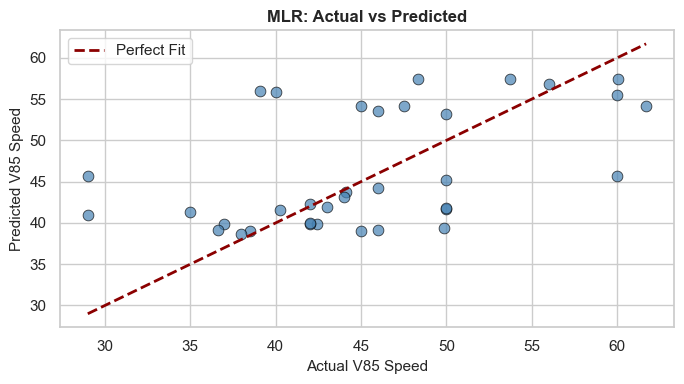

In [91]:
# ============================================================
# MLR: ACTUAL VERSUS PREDICTED
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_mlr,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed")
plt.ylabel("Predicted V85 Speed")

plt.title(
    "MLR: Actual vs Predicted",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()

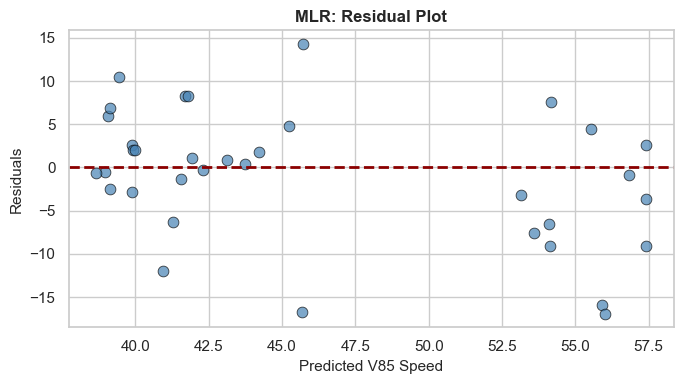

In [92]:
# ============================================================
# MLR: RESIDUAL PLOT
# ============================================================

mlr_residuals = (
    y_test -
    y_test_pred_mlr
)

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.scatterplot(
    x=y_test_pred_mlr,
    y=mlr_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    linestyle="--",
    color="darkred",
    linewidth=2
)

plt.xlabel("Predicted V85 Speed")
plt.ylabel("Residuals")

plt.title(
    "MLR: Residual Plot",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [93]:
# ============================================================
# FINAL MLR RESULT
# ============================================================

mlr_final = pd.DataFrame({
    "Model": ["MLR"],
    "R2": [
        round(
            mlr_test_r2,
            3
        )
    ],
    "RMSE": [
        round(
            mlr_test_rmse,
            3
        )
    ],
    "MAE": [
        round(
            mlr_test_mae,
            3
        )
    ]
})

display(mlr_final)

,Model,R2,RMSE,MAE
0,MLR,0.127,7.494,5.718


In [94]:
# ============================================================
# CHECK UNSCALED TRAINING AND TESTING DATA
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nPredictors used:")

for column in X_train.columns:
    print(column)

X_train shape: (140, 4)
X_test shape : (35, 4)
y_train shape: (140,)
y_test shape : (35,)

Predictors used:
Gradient
Radius of Curve
Carriageway Width
Average Shoulder Width


In [95]:
# ============================================================
# TRAIN BASE RANDOM FOREST
# Unscaled predictors are used
# ============================================================

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

print("Base Random Forest trained successfully.")

Base Random Forest trained successfully.


In [96]:
# ============================================================
# TRAIN BASE RANDOM FOREST
# Unscaled predictors are used
# ============================================================

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

print("Base Random Forest trained successfully.")

Base Random Forest trained successfully.


In [97]:
# ============================================================
# BASE RANDOM FOREST PREDICTIONS
# ============================================================

y_train_pred_rf = rf.predict(
    X_train
)

y_test_pred_rf = rf.predict(
    X_test
)

print("Training predictions:", len(y_train_pred_rf))
print("Testing predictions :", len(y_test_pred_rf))

Training predictions: 140
Testing predictions : 35


In [98]:
# ============================================================
# BASE RANDOM FOREST EVALUATION
# ============================================================

# Training metrics
rf_train_r2 = r2_score(
    y_train,
    y_train_pred_rf
)

rf_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf
    )
)

rf_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf
)

# Testing metrics
rf_test_r2 = r2_score(
    y_test,
    y_test_pred_rf
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf
    )
)

rf_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf
)

print("Base Random Forest evaluation completed.")

Base Random Forest evaluation completed.


In [99]:
# ============================================================
# BASE RF: TRAINING VS TESTING RESULTS
# ============================================================

rf_train_test_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "R2": [
        rf_train_r2,
        rf_test_r2
    ],
    "RMSE": [
        rf_train_rmse,
        rf_test_rmse
    ],
    "MAE": [
        rf_train_mae,
        rf_test_mae
    ]
})

display(
    rf_train_test_results.round(3)
)

,Dataset,R2,RMSE,MAE
0,Training,0.929,2.885,2.154
1,Testing,0.034,7.886,6.201


In [100]:
# ============================================================
# BASE RF TEST-SET METRICS
# ============================================================

rf_results = pd.DataFrame({
    "Metric": [
        "R2",
        "RMSE",
        "MAE"
    ],
    "Value": [
        rf_test_r2,
        rf_test_rmse,
        rf_test_mae
    ]
})

display(
    rf_results.round(3)
)

,Metric,Value
0,R2,0.034
1,RMSE,7.886
2,MAE,6.201


In [101]:
# ============================================================
# BASE RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_importance.round(4)
)

,Feature,Importance
0,Radius of Curve,0.632
1,Gradient,0.227
2,Average Shoulder Width,0.085
3,Carriageway Width,0.056


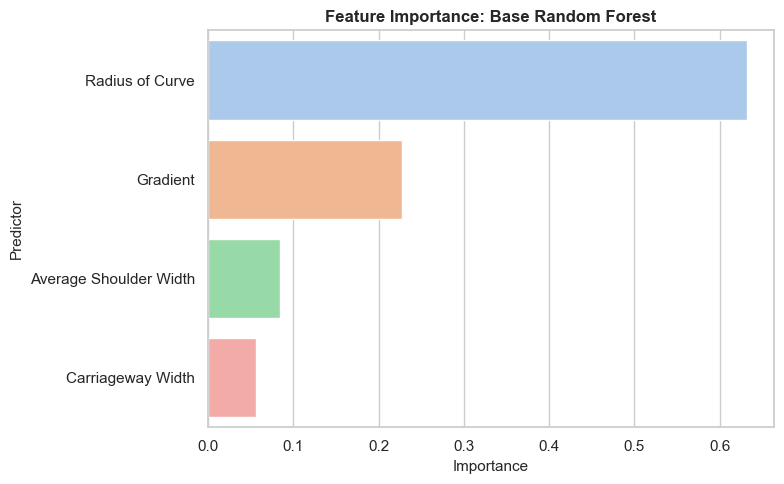

In [102]:
# ============================================================
# BASE RF FEATURE-IMPORTANCE PLOT
# ============================================================

sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature",
    palette="pastel"
)

plt.title(
    "Feature Importance: Base Random Forest",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

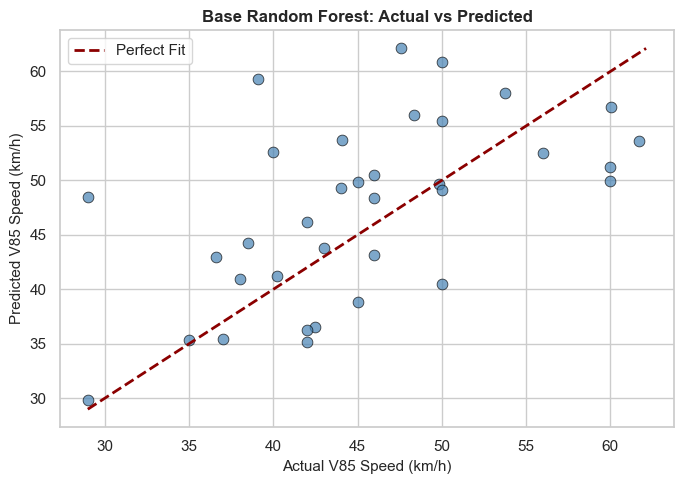

In [103]:
# ============================================================
# BASE RF: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test,
    y=y_test_pred_rf,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

minimum_value = min(
    y_test.min(),
    y_test_pred_rf.min()
)

maximum_value = max(
    y_test.max(),
    y_test_pred_rf.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="darkred",
    linestyle="--",
    linewidth=2,
    label="Perfect Fit"
)

plt.xlabel("Actual V85 Speed (km/h)")
plt.ylabel("Predicted V85 Speed (km/h)")

plt.title(
    "Base Random Forest: Actual vs Predicted",
    fontsize=12,
    fontweight="bold"
)

plt.legend()
plt.tight_layout()
plt.show()

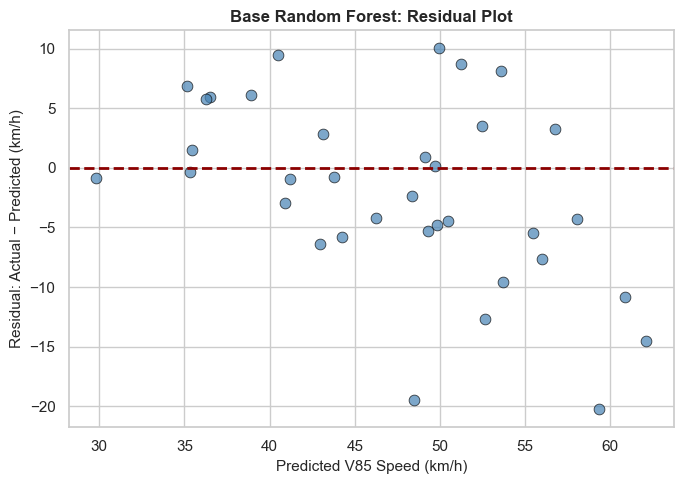

In [104]:
# ============================================================
# BASE RF: RESIDUAL PLOT
# ============================================================

rf_residuals = (
    y_test -
    y_test_pred_rf
)

plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_pred_rf,
    y=rf_residuals,
    color="steelblue",
    s=60,
    alpha=0.7,
    edgecolor="black"
)

plt.axhline(
    y=0,
    color="darkred",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted V85 Speed (km/h)")
plt.ylabel("Residual: Actual − Predicted (km/h)")

plt.title(
    "Base Random Forest: Residual Plot",
    fontsize=12,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# STORE BASE RANDOM FOREST RESULT
# ============================================================

rf_final = pd.DataFrame({
    "Model": [
        "Base Random Forest"
    ],
    "R2": [
        rf_test_r2
    ],
    "RMSE": [
        rf_test_rmse
    ],
    "MAE": [
        rf_test_mae
    ]
})

display(
    rf_final.round(3)
)

,Model,R2,RMSE,MAE
0,Base Random Forest,0.034,7.886,6.201


In [106]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER GRID
# ============================================================

param_grid_rf = {
    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10,
        15
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        4
    ],

    "max_features": [
        "sqrt",
        "log2"
    ]
}

print("Random Forest parameter grid created.")

Random Forest parameter grid created.


In [107]:
# ============================================================
# CONFIGURE RANDOM FOREST GRID SEARCH
# ============================================================

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid_rf,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=1,

    return_train_score=True
)

print("Random Forest GridSearchCV configured.")

Random Forest GridSearchCV configured.


In [108]:
# ============================================================
# RUN RANDOM FOREST GRID SEARCH
# ============================================================

grid_rf.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed.")

print("\nBest parameters:")
print(grid_rf.best_params_)

print(
    "\nBest mean cross-validation R2:",
    round(grid_rf.best_score_, 4)
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest tuning completed.

Best parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best mean cross-validation R2: 0.4776


In [109]:
# ============================================================
# RUN RANDOM FOREST GRID SEARCH
# ============================================================

grid_rf.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed.")

print("\nBest parameters:")
print(grid_rf.best_params_)

print(
    "\nBest mean cross-validation R2:",
    round(grid_rf.best_score_, 4)
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest tuning completed.

Best parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Best mean cross-validation R2: 0.4776


In [110]:
# ============================================================
# EXTRACT BEST RANDOM FOREST MODEL
# ============================================================

best_rf = grid_rf.best_estimator_

print("Best tuned Random Forest model extracted.")

print(best_rf)

Best tuned Random Forest model extracted.
RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_split=10,
                      random_state=42)


In [111]:
# ============================================================
# TUNED RANDOM FOREST PREDICTIONS
# ============================================================

y_train_pred_rf_tuned = best_rf.predict(
    X_train
)

y_test_pred_rf_tuned = best_rf.predict(
    X_test
)

print("Tuned RF training predictions:",
      len(y_train_pred_rf_tuned))

print("Tuned RF testing predictions :",
      len(y_test_pred_rf_tuned))

Tuned RF training predictions: 140
Tuned RF testing predictions : 35


In [112]:
# ============================================================
# TUNED RANDOM FOREST EVALUATION
# ============================================================

# Training performance
rf_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_rf_tuned
)

rf_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_rf_tuned
    )
)

rf_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_rf_tuned
)

# Testing performance
rf_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_rf_tuned
)

rf_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_rf_tuned
    )
)

rf_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_rf_tuned
)

print("Tuned Random Forest evaluation completed.")

Tuned Random Forest evaluation completed.


In [113]:
# ============================================================
# TUNED RF: TRAINING VS TESTING RESULTS
# ============================================================

rf_tuned_train_test_results = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "R2": [
        rf_tuned_train_r2,
        rf_tuned_test_r2
    ],
    "RMSE": [
        rf_tuned_train_rmse,
        rf_tuned_test_rmse
    ],
    "MAE": [
        rf_tuned_train_mae,
        rf_tuned_test_mae
    ]
})

display(
    rf_tuned_train_test_results.round(3)
)

,Dataset,R2,RMSE,MAE
0,Training,0.746,5.439,3.888
1,Testing,0.201,7.171,5.632


In [114]:
# ============================================================
# TUNED RF TEST-SET METRICS
# ============================================================

rf_tuned_results = pd.DataFrame({
    "Metric": [
        "R2",
        "RMSE",
        "MAE"
    ],
    "Value": [
        rf_tuned_test_r2,
        rf_tuned_test_rmse,
        rf_tuned_test_mae
    ]
})

display(
    rf_tuned_results.round(3)
)

,Metric,Value
0,R2,0.201
1,RMSE,7.171
2,MAE,5.632


In [116]:
# ============================================================
# INFLUENTIAL OBSERVATION ANALYSIS FOR MLR
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm

# Create average shoulder width
df["Average Shoulder Width"] = (
    df["Left Shoulder Width"] +
    df["Right Shoulder Width"]
) / 2

# Selected predictors
selected_predictors = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

X_influence = df[selected_predictors].astype(float)
y_influence = df["V85 Speed"].astype(float)

# Add intercept
X_influence_constant = sm.add_constant(
    X_influence,
    has_constant="add"
)

# Fit OLS model
ols_influence_model = sm.OLS(
    y_influence,
    X_influence_constant
).fit()

# Influence statistics
influence = ols_influence_model.get_influence()

cooks_distance = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag
studentized_residual = influence.resid_studentized_external

n = len(df)
number_of_parameters = X_influence_constant.shape[1]

# Common diagnostic thresholds
cooks_threshold = 4 / n
leverage_threshold = 2 * number_of_parameters / n

influence_table = df[
    [
        "SN",
        "V85 Speed",
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Average Shoulder Width"
    ]
].copy()

influence_table["Cooks Distance"] = cooks_distance
influence_table["Leverage"] = leverage
influence_table["Studentized Residual"] = studentized_residual

influence_table["Cook Flag"] = (
    influence_table["Cooks Distance"] >
    cooks_threshold
)

influence_table["Leverage Flag"] = (
    influence_table["Leverage"] >
    leverage_threshold
)

influence_table["Residual Flag"] = (
    influence_table["Studentized Residual"].abs() > 3
)

influence_table["Any Flag"] = (
    influence_table[
        [
            "Cook Flag",
            "Leverage Flag",
            "Residual Flag"
        ]
    ].any(axis=1)
)

print("Cook's distance threshold:",
      round(cooks_threshold, 4))

print("Leverage threshold:",
      round(leverage_threshold, 4))

print(
    "Number exceeding Cook's threshold:",
    influence_table["Cook Flag"].sum()
)

print(
    "Number with high leverage:",
    influence_table["Leverage Flag"].sum()
)

print(
    "Number with |studentized residual| > 3:",
    influence_table["Residual Flag"].sum()
)

flagged_observations = (
    influence_table[
        influence_table["Any Flag"]
    ]
    .sort_values(
        "Cooks Distance",
        ascending=False
    )
)

display(
    flagged_observations.round(4)
)

Cook's distance threshold: 0.0229
Leverage threshold: 0.0571
Number exceeding Cook's threshold: 10
Number with high leverage: 1
Number with |studentized residual| > 3: 1


,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Average Shoulder Width,Cooks Distance,Leverage,Studentized Residual,Cook Flag,Leverage Flag,Residual Flag,Any Flag
134,135,28.900,1.380,1500.000,7.000,0.250,0.067,0.031,-3.325,True,False,True,True
28,29,61.000,0.287,60.000,4.944,0.300,0.055,0.049,2.349,True,False,False,True
93,94,65.650,7.920,200.000,6.000,0.000,0.043,0.035,2.468,True,False,False,True
5,6,74.000,3.160,1500.000,5.500,0.900,0.041,0.030,2.613,True,False,False,True
97,98,72.000,6.475,1500.000,7.000,0.375,0.027,0.035,1.960,True,False,False,True
12,13,39.100,0.500,1500.000,7.500,0.645,0.025,0.035,-1.862,True,False,False,True
132,133,61.300,7.690,100.000,7.000,0.250,0.025,0.028,2.086,True,False,False,True
87,88,24.000,1.785,15.000,6.000,0.250,0.024,0.025,-2.198,True,False,False,True
70,71,38.400,5.050,1500.000,7.000,1.000,0.024,0.037,-1.763,True,False,False,True
74,75,67.250,0.700,1500.000,7.000,1.000,0.023,0.037,1.743,True,False,False,True


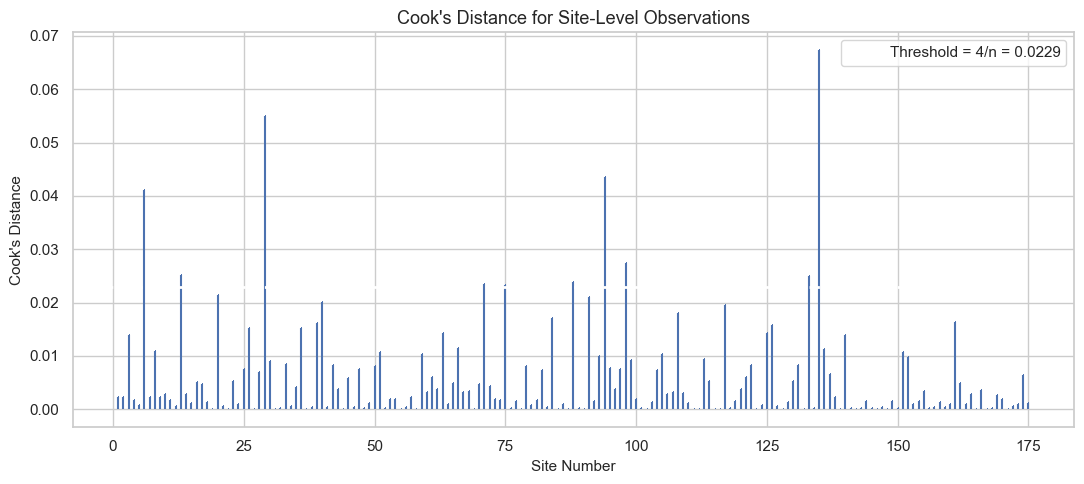

In [117]:
# ============================================================
# COOK'S DISTANCE PLOT
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.stem(
    df["SN"],
    cooks_distance,
    markerfmt=",",
    basefmt=" "
)

plt.axhline(
    cooks_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = 4/n = {cooks_threshold:.4f}"
)

plt.xlabel("Site Number")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance for Site-Level Observations")
plt.legend()
plt.tight_layout()
plt.show()

In [118]:
# ============================================================
# DEFINE OBSERVATIONS FLAGGED BY INFLUENCE ANALYSIS
# ============================================================

flagged_sn = [
    135,
    29,
    94,
    6,
    98,
    13,
    133,
    88,
    71,
    75,
    161
]

print("Number of flagged observations:", len(flagged_sn))
print("Flagged SN values:", flagged_sn)

Number of flagged observations: 11
Flagged SN values: [135, 29, 94, 6, 98, 13, 133, 88, 71, 75, 161]


In [119]:
# ============================================================
# DISPLAY FLAGGED OBSERVATIONS
# ============================================================

flagged_data = (
    df[
        df["SN"].isin(flagged_sn)
    ]
    .copy()
    .sort_values("SN")
)

display(
    flagged_data[
        [
            "SN",
            "V85 Speed",
            "Gradient",
            "Radius of Curve",
            "Carriageway Width",
            "Left Shoulder Width",
            "Right Shoulder Width",
            "Average Shoulder Width"
        ]
    ]
)

print(
    "Number of matching observations:",
    len(flagged_data)
)

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
5,6,74.000,3.160,1500.000,5.500,0.900,0.900,0.900
12,13,39.100,0.500,1500.000,7.500,0.590,0.700,0.645
28,29,61.000,0.287,60.000,4.944,0.000,0.600,0.300
70,71,38.400,5.050,1500.000,7.000,1.000,1.000,1.000
74,75,67.250,0.700,1500.000,7.000,1.000,1.000,1.000
87,88,24.000,1.785,15.000,6.000,0.000,0.500,0.250
93,94,65.650,7.920,200.000,6.000,0.000,0.000,0.000
97,98,72.000,6.475,1500.000,7.000,0.750,0.000,0.375
132,133,61.300,7.690,100.000,7.000,0.500,0.000,0.250
134,135,28.900,1.380,1500.000,7.000,0.500,0.000,0.250


Number of matching observations: 11
